<a href="https://colab.research.google.com/github/Gabbycodez/Gabby-s-todo-list-project/blob/main/Modality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Multi-Omic Cohort of 111 patients with Major Depressive Disorder

*   Each patient is profiled across three molecular layers: genotype comprising 258,782 single-nucleotide polymorphisms, gene expression comprising 1,572 genes, and DNA methylation comprising 13,900 cytosine sites.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Adjust this to wherever your files actually live in Drive
DATA_DIR = '/content/drive/MyDrive/Data_Sairi'
print(os.listdir(DATA_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['DNA_methylation_input.csv', 'GenePT_gene_embedding_ada_text.pickle', 'Gene_expression_input.csv', 'Genotype_input.csv', 'Geneset_entries.csv', 'MADRS.csv', 'Patient_condition.csv']


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score
from scipy.spatial.distance import cdist
import torch
import torch.nn as nn # Added this line
import torch.nn.functional as F
import copy

torch.manual_seed(0)
np.random.seed(0)

Load, align, and build both modality sets

In [ ]:
condition = pd.read_csv(os.path.join(DATA_DIR, 'Patient_condition.csv'))
condition['ID'] = condition['ID'].astype(str)
condition = condition.set_index('ID')
y_series = (condition['RES'] == 'RES').astype(int)

def load_omic(path, feature_col):
    df = pd.read_csv(path).set_index(feature_col).T
    df.index = df.index.astype(str)
    return df

geno = load_omic(os.path.join(DATA_DIR, 'Genotype_input.csv'), 'SNP')
expr = load_omic(os.path.join(DATA_DIR, 'Gene_expression_input.csv'), 'Gene')
meth = load_omic(os.path.join(DATA_DIR, 'DNA_methylation_input.csv'), 'CpG_sites')

common_ids = geno.index.intersection(expr.index).intersection(meth.index).intersection(y_series.index)
common_ids = sorted(common_ids, key=lambda x: int(x))

geno, expr, meth = geno.loc[common_ids], expr.loc[common_ids], meth.loc[common_ids]
y = y_series.loc[common_ids].values

modalities = {'genotype': geno.values.astype(np.float32),
              'expression': expr.values.astype(np.float32),
              'methylation': meth.values.astype(np.float32)}

modalities_no_genotype = {'expression': modalities['expression'],
                           'methylation': modalities['methylation']}

print("n patients:", len(common_ids))
print("y distribution:", np.bincount(y))
for name, X in modalities.items():
    print(name, X.shape)

n patients: 111
y distribution: [50 61]
genotype (111, 258782)
expression (111, 1572)
methylation (111, 13900)


#**Within-fold preprocessing**
- We select the best 200 features that contain useful information.

This is way faster to compute, as well as it way too many features while its too few patients (Causes overfitting since the model would start remembering) and it stops us from feeding the model too much noise.

# 10 Fold Cross Validation
We do the 10 fold to ensure the training data receive the information from the test set.
We split data before we train and test.

#The most important function -> preprocess_fold()

- X_train = training patients
- X_test = patients the model never seen before

- y_train = training labels
- y_test = This is not in the function to ensure we do not know the answers for the test patients

- k_features = 200

- We compute the average of every feature without missing values of the training patients to ensure we are not including the test patients since they would influence the preprocessing

- We use ANOVA to grade how well it separates the responders from non responsers using an F-score

- We make sure we are using those top 200 features from the training data

Summary:
For each cross-validation fold, we first replace missing values in the training data using the average value of each feature. We use those same averages to fill missing values in the test data. Next, we perform ANOVA feature selection on the training data only to identify the 200 most informative features, and we keep those same features in the test set. Finally, we standardize the data using the training set's mean and standard deviation, then apply that scaling to both the training and test sets



In [ ]:
def preprocess_fold(X_train, X_test, y_train, k_features=200):
    col_means = np.nanmean(X_train, axis=0)
    X_train = np.where(np.isnan(X_train), col_means, X_train)
    X_test = np.where(np.isnan(X_test), col_means, X_test)

    f_scores, _ = f_classif(X_train, y_train)
    f_scores = np.nan_to_num(f_scores)
    top_idx = np.argsort(f_scores)[-k_features:]
    X_train, X_test = X_train[:, top_idx], X_test[:, top_idx]

    scaler = StandardScaler().fit(X_train)
    return scaler.transform(X_train), scaler.transform(X_test)

# The three simple baseline strategies

Single layer: just train one plain classifier using one modality (e.g., only methylation) and see how well it predicts on its own.

Early fusion: glue all three modalities' cleaned features into one big table, then train a single classifier on the combined thing.

Late fusion: train three separate classifiers (one per modality), get each one's prediction, then just average the three predictions together.

In [ ]:
def eval_single_layer(X, y, train_idx, test_idx, k_features=200):
    Xtr, Xte = preprocess_fold(X[train_idx], X[test_idx], y[train_idx], k_features)
    clf = LogisticRegression(max_iter=2000, C=1.0).fit(Xtr, y[train_idx])
    return clf.predict_proba(Xte)[:, 1]

def eval_early_fusion(modalities, y, train_idx, test_idx, k_features=200):
    Xtr_all, Xte_all = [], []
    for X in modalities.values():
        Xtr, Xte = preprocess_fold(X[train_idx], X[test_idx], y[train_idx], k_features)
        Xtr_all.append(Xtr); Xte_all.append(Xte)
    Xtr_all, Xte_all = np.hstack(Xtr_all), np.hstack(Xte_all)
    clf = LogisticRegression(max_iter=2000, C=1.0).fit(Xtr_all, y[train_idx])
    return clf.predict_proba(Xte_all)[:, 1]

def eval_late_fusion(modalities, y, train_idx, test_idx, k_features=200):
    all_probs = [eval_single_layer(X, y, train_idx, test_idx, k_features) for X in modalities.values()]
    return np.mean(all_probs, axis=0)

# Building the "patient similarity" graph and the mini neural network
Two things happen here:

build_knn_graph: For each patient, find their 10 most similar patients (based on that modality's data) and connect them. This turns the data into a network/graph — think of it like a friendship map, where "similar patients" are linked.

normalize_adj: A bit of standard math bookkeeping so the network's connections don't add up unevenly (some patients might have more connections than others) — this keeps the math balanced. You don't need to understand the formula deeply, just that it's a standard prep step for graph neural networks.

GCNEncoder: This is a small neural network that looks at each patient's data and their neighbors' data (via the graph) to build a compressed summary (a list of 32 numbers) representing that patient, for that one modality.

In [ ]:
def build_knn_graph(X, k=10):
    """
    Build a symmetric weighted k-NN graph using cosine similarity.
    Matches the MOGONET paper more closely than a binary Euclidean graph.
    """
    k = min(k, X.shape[0] - 1)
    S = cosine_similarity(X)

    np.fill_diagonal(S, 0)

    n = len(S)
    A = np.zeros_like(S)

    for i in range(n):
        nbrs = np.argsort(S[i])[-k:]
        A[i, nbrs] = S[i, nbrs]

    # Symmetrize
    A = np.maximum(A, A.T)

    return A

def normalize_adj(A):
    A_hat = A + np.eye(A.shape[0])
    D = np.diag(1.0 / np.sqrt(A_hat.sum(1)))
    return D @ A_hat @ D

# Training one modality's mini-model

ModalityModel = the graph encoder from Cell 5, plus one more small layer on top that turns the 32-number summary into an actual prediction (responder vs. non-responder).

train_modality_model just runs the standard training loop: show the model the data, measure how wrong it is, adjust the model slightly, repeat 150 times. This happens completely separately for genotype, expression, and methylation — three independent mini-models.

In [ ]:
class GraphConv(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=True)

    def forward(self, X, A):
        return A @ self.W(X)


class GCNEncoder(nn.Module):
    def __init__(self, in_dim,
                 hidden1=200,
                 hidden2=200,
                 out_dim=100,
                 dropout=0.5):
        super().__init__()

        self.gc1 = GraphConv(in_dim, hidden1)
        self.gc2 = GraphConv(hidden1, hidden2)
        self.gc3 = GraphConv(hidden2, out_dim)

        self.dropout = dropout

    def forward(self, X, A):

        X = F.leaky_relu(self.gc1(X, A), 0.25)
        X = F.dropout(X, self.dropout, training=self.training)

        X = F.leaky_relu(self.gc2(X, A), 0.25)
        X = F.dropout(X, self.dropout, training=self.training)

        X = F.leaky_relu(self.gc3(X, A), 0.25)

        return X

class ModalityModel(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.encoder = GCNEncoder(in_dim)
        self.head = nn.Linear(100, 2)

    def forward(self, X, A_norm):
        return self.head(self.encoder(X, A_norm))

def train_modality_model_masked(X_all, A_norm, y_labeled, train_positions, epochs=100, lr=0.005):
    model = ModalityModel(X_all.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    X_t = torch.tensor(X_all, dtype=torch.float32)
    A_t = torch.tensor(A_norm, dtype=torch.float32)
    y_t = torch.tensor(y_labeled, dtype=torch.long)
    train_pos_t = torch.tensor(train_positions, dtype=torch.long)

    for _ in range(epochs):
        opt.zero_grad()
        logits_all = model(X_t, A_t)
        loss = F.cross_entropy(logits_all[train_pos_t], y_t)
        loss.backward()
        opt.step()
    return model

def train_modality_model_masked_ensemble(X_all, A_norm, y_labeled, train_positions,
                                          n_runs=3, epochs=200, lr=0.005):
    """Averages n_runs training runs for stability -- our addition, not in the original paper."""
    all_logits = []
    X_t = torch.tensor(X_all, dtype=torch.float32)
    A_t = torch.tensor(A_norm, dtype=torch.float32)
    for seed in range(n_runs):
        torch.manual_seed(seed)
        model = train_modality_model_masked(X_all, A_norm, y_labeled, train_positions, epochs=epochs, lr=lr)
        with torch.no_grad():
            all_logits.append(model(X_t, A_t))
    return torch.stack(all_logits).mean(dim=0)

# The actual "smart weighting" trick (SGOF)
The weighting step is what distinguishes the procedure from conventional fusion.

We take the training patients and split them again into two groups: a smaller "inner training" group and a smaller "inner checking" group. Neither of these touches the real test patients — this is all still happening inside "training."

 Each modality is encoded by an independent two-layer graph convolutional network that maps the input features to a hidden representation of width 64 and then to an embedding of width 32, with rectified-linear activations and dropout. A per-modality linear head maps each embedding to class logits.

Then we check how well that mini-model predicts the "inner checking" group — patients it never trained on. This score tells us: does this modality actually carry real, generalizable signal, or was it just memorizing noise?

If a modality's checking score is basically 50/50 guessing (no better than a coin flip), we say it has zero usable signal, and its "weight" becomes 0. If it does meaningfully better than a coin flip, it gets a proportionally bigger weight.

Once we know the weights, we retrain each modality's model one more time — this time using all the training patients (not just the inner subset) — and generate its final prediction on the real test patients.
The final answer = a weighted blend of each modality's prediction, using the weights we calculated in step 4.

> The reason this works: a big noisy modality like genotype can still "fit" its own training data well by essentially memorizing coincidences — but it can't fake doing well on patients it's never seen. So checking performance on unseen "inner checking" patients is what exposes it as useless and drives its weight toward zero.

The idea is not novel in isolation, since weighting predictors by held-out performance is a standard practice; its value here is as a minimal and interpretable remedy for the specific failure we document.

Unless otherwise stated, all reported figures use repeated stratified cross-validation with ten folds repeated ten times, yielding one hundred held-out estimates, and we report the mean and standard deviation of the area under the receiver operating characteristic curve. For the graph-convolutional methods, which are more computationally intensive, we use five-fold cross-validation, and we note this difference where relevant. We assess significance using label-permutation tests [20], and we quantify uncertainty in key comparisons using the bootstrap. Our primary metric is the area under the receiver operating characteristic curve because the cohort is modestly imbalanced and the metric is threshold independent.


In [ ]:
def eval_sgof(modalities, y, train_idx, test_idx, k_features=200, n_runs=3, verbose=False):
    inner_train_idx, inner_val_idx = train_test_split(
        train_idx, test_size=0.25, stratify=y[train_idx], random_state=0
    )

    weights = {}
    test_logits = {}

    for name, X in modalities.items():
        # Step 1: score modality signal -- feature selection using ONLY inner-train
        X_in_tr, X_in_val = preprocess_fold(X[inner_train_idx], X[inner_val_idx], y[inner_train_idx], k_features)
        X_inner_all = np.vstack([X_in_tr, X_in_val])
        n_inner_train = X_in_tr.shape[0]
        A_inner_all = normalize_adj(build_knn_graph(X_inner_all, k=10))

        inner_logits = train_modality_model_masked_ensemble(
            X_inner_all, A_inner_all, y[inner_train_idx],
            train_positions=np.arange(n_inner_train), n_runs=n_runs
        )
        val_probs = F.softmax(inner_logits[n_inner_train:], dim=1)[:, 1].numpy()
        a_m = roc_auc_score(y[inner_val_idx], val_probs)
        weights[name] = max(a_m - 0.5, 0)

        # Step 2: full outer-train feature selection, real test prediction
        Xtr_full, Xte = preprocess_fold(X[train_idx], X[test_idx], y[train_idx], k_features)
        X_full_all = np.vstack([Xtr_full, Xte])
        n_tr = Xtr_full.shape[0]
        A_full_all = normalize_adj(build_knn_graph(X_full_all, k=10))

        final_logits = train_modality_model_masked_ensemble(
            X_full_all, A_full_all, y[train_idx],
            train_positions=np.arange(n_tr), n_runs=n_runs
        )
        test_logits[name] = final_logits[n_tr:]

        if verbose:
            print(f"    [{name}] logit magnitude: {test_logits[name].abs().mean().item():.3f}, "
                  f"solo test AUROC: {roc_auc_score(y[test_idx], F.softmax(test_logits[name], dim=1)[:,1].detach().numpy()):.3f}")

    total_s = sum(weights.values())
    if total_s == 0:
        weights = {k: 1/len(weights) for k in weights}
    else:
        weights = {k: v/total_s for k, v in weights.items()}

    # weighted sum of logits (paper's Eq. 1), scale-normalized per modality first
    normalized_logits = {name: test_logits[name] / (test_logits[name].std().item() + 1e-6) for name in modalities}
    fused_logits = sum(weights[name] * normalized_logits[name] for name in modalities)
    fused_probs = F.softmax(fused_logits, dim=1)[:, 1].detach().numpy()

    return fused_probs, weights

# XGBoost early fusion baseline

In [ ]:
from xgboost import XGBClassifier

def eval_early_fusion_xgb(modalities, y, train_idx, test_idx, k_features=200):
    Xtr_all, Xte_all = [], []
    for X in modalities.values():
        Xtr, Xte = preprocess_fold(X[train_idx], X[test_idx], y[train_idx], k_features)
        Xtr_all.append(Xtr); Xte_all.append(Xte)
    Xtr_all, Xte_all = np.hstack(Xtr_all), np.hstack(Xte_all)
    clf = XGBClassifier(n_estimators=100, max_depth=2, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.5, eval_metric='logloss', random_state=0)
    clf.fit(Xtr_all, y[train_idx])
    return clf.predict_proba(Xte_all)[:, 1]

# Similarity Network Fusion (SNF) + label propagation

In [ ]:
def snf_similarity_kernel(X, k=10, mu=0.5):
    dist = cdist(X, X, metric='euclidean')
    knn_dist = np.sort(dist, axis=1)[:, 1:k+1]
    eps = knn_dist.mean(axis=1) + 1e-6
    sigma = mu * (eps[:, None] + eps[None, :]) / 2 + dist / 3 + 1e-6
    W = np.exp(-dist**2 / (2 * sigma**2))
    np.fill_diagonal(W, 0)
    return W

def snf_normalize(W):
    d = W.sum(axis=1, keepdims=True)
    d[d == 0] = 1e-6
    return W / d

def snf_knn_sparsify(W, k=10):
    S = np.zeros_like(W)
    for i in range(W.shape[0]):
        idx = np.argsort(-W[i])[:k]
        S[i, idx] = W[i, idx]
    return snf_normalize(S)

def similarity_network_fusion(modality_sims, k=10, t=20, mu=0.5):
    Ps = [snf_normalize(W) for W in modality_sims]
    Ss = [snf_knn_sparsify(W, k) for W in modality_sims]
    m = len(Ps)
    for _ in range(t):
        new_Ps = []
        for v in range(m):
            avg_other = sum(Ps[u] for u in range(m) if u != v) / (m - 1)
            new_Ps.append(snf_normalize(Ss[v] @ avg_other @ Ss[v].T))
        Ps = new_Ps
    return sum(Ps) / m

def label_propagation(W, y_train, train_positions, test_positions, alpha=0.9, n_iter=50):
    n = W.shape[0]
    d = W.sum(axis=1); d[d == 0] = 1e-6
    S = np.diag(1.0/np.sqrt(d)) @ W @ np.diag(1.0/np.sqrt(d))

    Y = np.zeros((n, 2))
    for pos, label in zip(train_positions, y_train):
        Y[pos, label] = 1.0

    F_mat = Y.copy()
    for _ in range(n_iter):
        F_mat = alpha * (S @ F_mat) + (1 - alpha) * Y

    probs = F_mat[test_positions, 1] / (F_mat[test_positions].sum(axis=1) + 1e-6)
    return probs

def eval_snf(modalities, y, train_idx, test_idx, k_features=200):
    n_tr = len(train_idx)
    sims = []
    for X in modalities.values():
        Xtr, Xte = preprocess_fold(X[train_idx], X[test_idx], y[train_idx], k_features)
        sims.append(snf_similarity_kernel(np.vstack([Xtr, Xte]), k=10))
    W_fused = similarity_network_fusion(sims, k=10, t=20)
    return label_propagation(W_fused, y[train_idx], np.arange(n_tr), np.arange(n_tr, n_tr + len(test_idx)))

# MOGONET

In [33]:
class VCDN(nn.Module):

    def __init__(self,
                 n_modalities,
                 n_classes=2):

        super().__init__()

        self.n_classes = n_classes

        self.net = nn.Sequential(

            nn.Linear(
                n_classes ** n_modalities,
                n_classes ** n_modalities
            ),

            nn.LeakyReLU(0.25),

            nn.Linear(
                n_classes ** n_modalities,
                n_classes
            )
        )

        # Xavier initialization
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, logits_list):

        probs = [torch.sigmoid(x) for x in logits_list]

        x = probs[0]

        for p in probs[1:]:
            x = torch.einsum(
                "bi,bj->bij",
                x,
                p
            ).reshape(x.shape[0], -1)

        return self.net(x)

def eval_mogonet(modalities, y, train_idx, test_idx, k_features=200,
                 pretrain_epochs=200,
                 joint_epochs=50, # Reduced joint training epochs
                 lr=0.005,
                 early_stopping_patience=10):

    n_tr = len(train_idx)

    models = {}
    graphs = {}
    X_alls = {}

    # ============================================================
    # Stage 1: Pretrain each modality independently
    # ============================================================

    for name, X in modalities.items():

        Xtr, Xte = preprocess_fold(
            X[train_idx],
            X[test_idx],
            y[train_idx],
            k_features
        )

        X_all = np.vstack([Xtr, Xte])

        A = normalize_adj(
            build_knn_graph(X_all, k=10)
        )

        graphs[name] = torch.tensor(
            A,
            dtype=torch.float32
        )

        X_alls[name] = torch.tensor(
            X_all,
            dtype=torch.float32
        )

        model = train_modality_model_masked(
            X_all=X_all,
            A_norm=A,
            y_labeled=y[train_idx],
            train_positions=np.arange(n_tr),
            epochs=pretrain_epochs,
            lr=lr
        )

        models[name] = model

    # ============================================================
    # Stage 2: Jointly train VCDN + modality models with early stopping
    # ============================================================

    # Create inner train/validation split for early stopping
    inner_train_fold_idx, inner_val_fold_idx = train_test_split(
        np.arange(n_tr), test_size=0.2, stratify=y[train_idx], random_state=42
    )

    y_t = torch.tensor(
        y[train_idx],
        dtype=torch.long
    )

    vcdn = VCDN(
        n_modalities=len(modalities)
    )

    params = list(vcdn.parameters())
    for model in models.values():
        params += list(model.parameters())

    optimizer = torch.optim.Adam(
        params,
        lr=lr,
        weight_decay=1e-4
    )

    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_vcdn_state = None
    best_models_states = {name: None for name in modalities}

    # Lists to store metrics for learning curves
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(joint_epochs):

        optimizer.zero_grad()

        logits_list = []

        for name in modalities:
            logits = models[name](
                X_alls[name],
                graphs[name]
            )
            logits_list.append(logits)

        fused_logits = vcdn(logits_list)

        # Calculate training loss
        current_train_loss = F.cross_entropy(
            fused_logits[inner_train_fold_idx],
            y_t[inner_train_fold_idx]
        )

        # Modality supervision loss
        for logits in logits_list:
            current_train_loss += F.cross_entropy(
                logits[inner_train_fold_idx],
                y_t[inner_train_fold_idx]
            )

        current_train_loss.backward()
        optimizer.step()

        # Evaluate on validation set for early stopping
        with torch.no_grad():
            val_logits_list = []
            for name in modalities:
                val_logits_list.append(models[name](X_alls[name], graphs[name]))
            val_fused_logits = vcdn(val_logits_list)

            current_val_loss = F.cross_entropy(
                val_fused_logits[inner_val_fold_idx],
                y_t[inner_val_fold_idx]
            )
            for logits in val_logits_list:
                current_val_loss += F.cross_entropy(
                    logits[inner_val_fold_idx],
                    y_t[inner_val_fold_idx]
                )

            # Calculate training accuracy
            train_preds = torch.argmax(fused_logits[inner_train_fold_idx], dim=1)
            current_train_accuracy = (train_preds == y_t[inner_train_fold_idx]).float().mean().item()

            # Calculate validation accuracy
            val_preds = torch.argmax(val_fused_logits[inner_val_fold_idx], dim=1)
            current_val_accuracy = (val_preds == y_t[inner_val_fold_idx]).float().mean().item()

        # Store metrics for learning curves
        train_losses.append(current_train_loss.item())
        val_losses.append(current_val_loss.item())
        train_accuracies.append(current_train_accuracy)
        val_accuracies.append(current_val_accuracy)

        # Early stopping logic
        if current_val_loss < best_val_loss:
            best_val_loss = current_val_loss
            epochs_no_improve = 0
            best_vcdn_state = vcdn.state_dict()
            for name, model in models.items():
                best_models_states[name] = model.state_dict()
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= early_stopping_patience:
            # print(f"Early stopping at epoch {epoch+1}") # For debugging
            break

    # Load best model states after early stopping
    if best_vcdn_state:
        vcdn.load_state_dict(best_vcdn_state)
    for name, model in models.items():
        if best_models_states[name]:
            model.load_state_dict(best_models_states[name])

    # ============================================================
    # Prediction
    # ============================================================

    with torch.no_grad():

        logits_list = []

        for name in modalities:

            logits = models[name](
                X_alls[name],
                graphs[name]
            )

            logits_list.append(logits)

        fused_logits = vcdn(logits_list)

        probs = torch.softmax(
            fused_logits,
            dim=1
        )[:, 1].numpy()

    return probs[n_tr:], {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies
    }

### Learning Curves for MOGONET (Training/Validation Loss and Accuracy)

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

# Re-define DATA_DIR if not already in global scope
if 'DATA_DIR' not in globals():
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/Data_Sairi'

# Re-load or ensure modalities and y are available
if 'modalities' not in globals() or 'y' not in globals():
    print("Reloading omic data.")
    def load_omic(path, feature_col):
        df = pd.read_csv(path).set_index(feature_col).T
        df.index = df.index.astype(str)
        return df

    condition = pd.read_csv(os.path.join(DATA_DIR, 'Patient_condition.csv'))
    condition['ID'] = condition['ID'].astype(str)
    condition = condition.set_index('ID')
    y_series = (condition['RES'] == 'RES').astype(int)

    geno = load_omic(os.path.join(DATA_DIR, 'Genotype_input.csv'), 'SNP')
    expr = load_omic(os.path.join(DATA_DIR, 'Gene_expression_input.csv'), 'Gene')
    meth = load_omic(os.path.join(DATA_DIR, 'DNA_methylation_input.csv'), 'CpG_sites')

    common_ids = geno.index.intersection(expr.index).intersection(meth.index).intersection(y_series.index)
    common_ids = sorted(common_ids, key=lambda x: int(x))

    geno, expr, meth = geno.loc[common_ids], expr.loc[common_ids], meth.loc[common_ids]
    y = y_series.loc[common_ids].values

    modalities = {'genotype': geno.values.astype(np.float32),
                  'expression': expr.values.astype(np.float32),
                  'methylation': meth.values.astype(np.float32)}

    modalities_no_genotype = {'expression': modalities['expression'],
                               'methylation': modalities['methylation']}

# Re-define preprocess_fold (from Mqr1XosvKC7G)
def preprocess_fold(X_train, X_test, y_train, k_features=200):
    col_means = np.nanmean(X_train, axis=0)
    X_train = np.where(np.isnan(X_train), col_means, X_train)
    X_test = np.where(np.isnan(X_test), col_means, X_test)

    f_scores, _ = f_classif(X_train, y_train)
    f_scores = np.nan_to_num(f_scores)
    top_idx = np.argsort(f_scores)[-k_features:]
    X_train, X_test = X_train[:, top_idx], X_test[:, top_idx]

    scaler = StandardScaler().fit(X_train)
    return scaler.transform(X_train), scaler.transform(X_test)

# Re-define build_knn_graph (from DgyFbiqLFgZ4)
def build_knn_graph(X, k=10):
    k = min(k, X.shape[0] - 1)
    S = cosine_similarity(X)
    np.fill_diagonal(S, 0)
    n = len(S)
    A = np.zeros_like(S)
    for i in range(n):
        nbrs = np.argsort(S[i])[-k:]
        A[i, nbrs] = S[i, nbrs]
    A = np.maximum(A, A.T)
    return A

# Re-define normalize_adj (from DgyFbiqLFgZ4)
def normalize_adj(A):
    A_hat = A + np.eye(A.shape[0])
    D = np.diag(1.0 / np.sqrt(A_hat.sum(1)))
    return D @ A_hat @ D

# Re-define GraphConv, GCNEncoder, ModalityModel (from 8wg9GJ35KS45)
class GraphConv(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=True)
    def forward(self, X, A):
        return A @ self.W(X)

class GCNEncoder(nn.Module):
    def __init__(self, in_dim, hidden1=200, hidden2=200, out_dim=100, dropout=0.5):
        super().__init__()
        self.gc1 = GraphConv(in_dim, hidden1)
        self.gc2 = GraphConv(hidden1, hidden2)
        self.gc3 = GraphConv(hidden2, out_dim)
        self.dropout = dropout

    def forward(self, X, A):
        X = F.leaky_relu(self.gc1(X, A), 0.25)
        X = F.dropout(X, self.dropout, training=self.training)
        X = F.leaky_relu(self.gc2(X, A), 0.25)
        X = F.dropout(X, self.dropout, training=self.training)
        X = F.leaky_relu(self.gc3(X, A), 0.25)
        return X

class ModalityModel(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.encoder = GCNEncoder(in_dim)
        self.head = nn.Linear(100, 2)
    def forward(self, X, A_norm):
        return self.head(self.encoder(X, A_norm))

# Re-define train_modality_model_masked (from 8wg9GJ35KS45)
def train_modality_model_masked(X_all, A_norm, y_labeled, train_positions, epochs=100, lr=0.005):
    model = ModalityModel(X_all.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    X_t = torch.tensor(X_all, dtype=torch.float32)
    A_t = torch.tensor(A_norm, dtype=torch.float32)
    y_t = torch.tensor(y_labeled, dtype=torch.long)
    train_pos_t = torch.tensor(train_positions, dtype=torch.long)
    for _ in range(epochs):
        opt.zero_grad()
        logits_all = model(X_t, A_t)
        loss = F.cross_entropy(logits_all[train_pos_t], y_t)
        loss.backward()
        opt.step()
    return model

# Re-define VCDN (from BvuLF2AfKhry)
class VCDN(nn.Module):
    def __init__(self, n_modalities, n_classes=2):
        super().__init__()
        self.n_classes = n_classes
        self.net = nn.Sequential(
            nn.Linear(n_classes ** n_modalities, n_classes ** n_modalities),
            nn.LeakyReLU(0.25),
            nn.Linear(n_classes ** n_modalities, n_classes)
        )
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, logits_list):
        probs = [torch.sigmoid(x) for x in logits_list]
        x = probs[0]
        for p in probs[1:]:
            x = torch.einsum("bi,bj->bij", x, p).reshape(x.shape[0], -1)
        return self.net(x)

# The eval_mogonet is already defined in cell BvuLF2AfKhry and now returns history
# We will call it directly.

# Initialize storage for MOGONET learning history across folds
mogonet_history_with_genotype = []
mogonet_history_without_genotype = []

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

print("Collecting MOGONET learning history across cross-validation folds...")
for fold_i, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(y)), y)):
    print(f"  Processing fold {fold_i+1}...")
    # MOGONET with Genotype
    _, history_with = eval_mogonet(modalities, y, train_idx, test_idx, joint_epochs=50)
    mogonet_history_with_genotype.append(history_with)

    # MOGONET without Genotype
    _, history_without = eval_mogonet(modalities_no_genotype, y, train_idx, test_idx, joint_epochs=50)
    mogonet_history_without_genotype.append(history_without)
print("MOGONET learning history collection complete.")

# Aggregate histories by averaging across folds
def aggregate_history(histories):
    max_epochs = max(len(h['train_losses']) for h in histories)
    avg_history = {
        'train_losses': np.zeros(max_epochs),
        'val_losses': np.zeros(max_epochs),
        'train_accuracies': np.zeros(max_epochs),
        'val_accuracies': np.zeros(max_epochs),
    }
    counts = np.zeros(max_epochs)

    for h in histories:
        num_epochs_this_fold = len(h['train_losses'])
        avg_history['train_losses'][:num_epochs_this_fold] += h['train_losses']
        avg_history['val_losses'][:num_epochs_this_fold] += h['val_losses']
        avg_history['train_accuracies'][:num_epochs_this_fold] += h['train_accuracies']
        avg_history['val_accuracies'][:num_epochs_this_fold] += h['val_accuracies']
        counts[:num_epochs_this_fold] += 1

    # Avoid division by zero for epochs not reached by any fold (due to early stopping)
    counts[counts == 0] = 1 # Replace 0 with 1 to prevent NaN, these epochs will remain 0.

    for key in avg_history:
        avg_history[key] /= counts

    return avg_history

avg_history_with = aggregate_history(mogonet_history_with_genotype)
avg_history_without = aggregate_history(mogonet_history_without_genotype)

# Create directory for learning curve plots
learning_curve_output_dir = "./learning_curves"
os.makedirs(learning_curve_output_dir, exist_ok=True)

# Plotting function
def plot_learning_curves(history, title_suffix, filename_suffix):
    epochs = range(1, len(history['train_losses']) + 1)

    # Plot Loss
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history['train_losses'], label='Training Loss', marker='o', markersize=4)
    plt.plot(epochs, history['val_losses'], label='Validation Loss', marker='x', markersize=4)
    plt.title(f'MOGONET Loss Curve {title_suffix}', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    png_loss_filename = os.path.join(learning_curve_output_dir, f'mogonet_loss_curve_{filename_suffix}.png')
    pdf_loss_filename = os.path.join(learning_curve_output_dir, f'mogonet_loss_curve_{filename_suffix}.pdf')
    plt.savefig(png_loss_filename, dpi=300)
    plt.savefig(pdf_loss_filename, dpi=300)
    print(f"Saved Loss PNG: {png_loss_filename}")
    print(f"Saved Loss PDF: {pdf_loss_filename}")
    plt.close()

    # Plot Accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history['train_accuracies'], label='Training Accuracy', marker='o', markersize=4)
    plt.plot(epochs, history['val_accuracies'], label='Validation Accuracy', marker='x', markersize=4)
    plt.title(f'MOGONET Accuracy Curve {title_suffix}', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.ylim(0, 1) # Accuracy is between 0 and 1
    plt.tight_layout()

    png_acc_filename = os.path.join(learning_curve_output_dir, f'mogonet_accuracy_curve_{filename_suffix}.png')
    pdf_acc_filename = os.path.join(learning_curve_output_dir, f'mogonet_accuracy_curve_{filename_suffix}.pdf')
    plt.savefig(png_acc_filename, dpi=300)
    plt.savefig(pdf_acc_filename, dpi=300)
    print(f"Saved Accuracy PNG: {png_acc_filename}")
    print(f"Saved Accuracy PDF: {pdf_acc_filename}")
    plt.close()

# Generate plots for 'With Genotype'
print("\nGenerating learning curve plots for MOGONET (With Genotype)...")
plot_learning_curves(avg_history_with, "(With Genotype)", "with_genotype")

# Generate plots for 'Without Genotype'
print("\nGenerating learning curve plots for MOGONET (Without Genotype)...")
plot_learning_curves(avg_history_without, "(Without Genotype)", "without_genotype")

print("\nAll MOGONET learning curve plots generated successfully!")

  Processing fold 1...
  Processing fold 2...
  Processing fold 3...
  Processing fold 4...
  Processing fold 5...
  Processing fold 6...
  Processing fold 7...
  Processing fold 8...
  Processing fold 9...
  Processing fold 10...
MOGONET learning history collection complete.

Generating learning curve plots for MOGONET (With Genotype)...
Saved Loss PNG: ./learning_curves/mogonet_loss_curve_with_genotype.png
Saved Loss PDF: ./learning_curves/mogonet_loss_curve_with_genotype.pdf
Saved Accuracy PNG: ./learning_curves/mogonet_accuracy_curve_with_genotype.png
Saved Accuracy PDF: ./learning_curves/mogonet_accuracy_curve_with_genotype.pdf

Generating learning curve plots for MOGONET (Without Genotype)...
Saved Loss PNG: ./learning_curves/mogonet_loss_curve_without_genotype.png
Saved Loss PDF: ./learning_curves/mogonet_loss_curve_without_genotype.pdf
Saved Accuracy PNG: ./learning_curves/mogonet_accuracy_curve_without_genotype.png
Saved Accuracy PDF: ./learning_curves/mogonet_accuracy_curve_w

# MoGCN (simplified: autoencoder + SNF + GCN)


In [ ]:
class SimpleAutoencoder(nn.Module):
    def __init__(self, in_dim, latent=32):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(in_dim, 64), nn.ReLU(), nn.Linear(64, latent))
        self.dec = nn.Sequential(nn.Linear(latent, 64), nn.ReLU(), nn.Linear(64, in_dim))

    def forward(self, x):
        z = self.enc(x)
        return self.dec(z), z

def train_autoencoder(X, epochs=150, lr=0.001):
    model = SimpleAutoencoder(X.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    X_t = torch.tensor(X, dtype=torch.float32)
    for _ in range(epochs):
        opt.zero_grad()
        recon, _ = model(X_t)
        loss = F.mse_loss(recon, X_t)
        loss.backward()
        opt.step()
    with torch.no_grad():
        _, z = model(X_t)
    return z.numpy()

def eval_mogcn(modalities, y, train_idx, test_idx, k_features=200):
    n_tr = len(train_idx)
    latents = []
    for X in modalities.values():
        Xtr, Xte = preprocess_fold(X[train_idx], X[test_idx], y[train_idx], k_features)
        latents.append(train_autoencoder(np.vstack([Xtr, Xte])))

    sims = [snf_similarity_kernel(z, k=10) for z in latents]
    A_fused = normalize_adj(similarity_network_fusion(sims, k=10, t=20))

    X_concat = np.hstack(latents)
    X_t = torch.tensor(X_concat, dtype=torch.float32)
    A_t = torch.tensor(A_fused, dtype=torch.float32)
    y_t = torch.tensor(y[train_idx], dtype=torch.long)
    train_pos = torch.arange(n_tr)

    model = ModalityModel(X_concat.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
    for _ in range(150):
        opt.zero_grad()
        loss = F.cross_entropy(model(X_t, A_t)[train_pos], y_t)
        loss.backward()
        opt.step()

    with torch.no_grad():
        probs = F.softmax(model(X_t, A_t), dim=1)[:, 1].numpy()
    return probs[n_tr:]

Unified outer loop (With vs. Without genotype, matching Table I)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def run_all_methods(mods, y, train_idx, test_idx):
    out = {}
    out['single_best'] = roc_auc_score(y[test_idx], eval_single_layer(mods['methylation'], y, train_idx, test_idx))
    out['early_fusion'] = roc_auc_score(y[test_idx], eval_early_fusion(mods, y, train_idx, test_idx))
    out['late_fusion'] = roc_auc_score(y[test_idx], eval_late_fusion(mods, y, train_idx, test_idx))
    out['early_fusion_xgb'] = roc_auc_score(y[test_idx], eval_early_fusion_xgb(mods, y, train_idx, test_idx))
    out['snf'] = roc_auc_score(y[test_idx], eval_snf(mods, y, train_idx, test_idx))
    out['mogonet'] = roc_auc_score(y[test_idx], eval_mogonet(mods, y, train_idx, test_idx))
    out['mogcn'] = roc_auc_score(y[test_idx], eval_mogcn(mods, y, train_idx, test_idx))
    probs_sgof, w = eval_sgof(mods, y, train_idx, test_idx)
    out['sgof'] = roc_auc_score(y[test_idx], probs_sgof)
    return out, w

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
method_names = ['single_best', 'early_fusion', 'late_fusion', 'early_fusion_xgb', 'snf', 'mogonet', 'mogcn', 'sgof']

results_with = {m: [] for m in method_names}
results_without = {m: [] for m in method_names}
sgof_weights_with, sgof_weights_without = [], []

for fold_i, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(y)), y)):
    print(f"--- Fold {fold_i+1} ---")

    out_with, w_with = run_all_methods(modalities, y, train_idx, test_idx)
    for m in method_names:
        results_with[m].append(out_with[m])
    sgof_weights_with.append(w_with)

    out_without, w_without = run_all_methods(modalities_no_genotype, y, train_idx, test_idx)
    for m in method_names:
        results_without[m].append(out_without[m])
    sgof_weights_without.append(w_without)

print("\n=== WITH genotype ===")
for m in method_names:
    print(f"{m}: {np.mean(results_with[m]):.3f} (+/- {np.std(results_with[m]):.3f})")

print("\n=== WITHOUT genotype ===")
for m in method_names:
    print(f"{m}: {np.mean(results_without[m]):.3f} (+/- {np.std(results_without[m]):.3f})")

print("\nSGOF weights WITH genotype:", {k: np.mean([w[k] for w in sgof_weights_with]) for k in modalities})
print("SGOF weights WITHOUT genotype:", {k: np.mean([w[k] for w in sgof_weights_without]) for k in modalities_no_genotype})

--- Fold 1 ---
--- Fold 2 ---
--- Fold 3 ---
--- Fold 4 ---
--- Fold 5 ---
--- Fold 6 ---
--- Fold 7 ---
--- Fold 8 ---
--- Fold 9 ---


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 44098 232948] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


--- Fold 10 ---

=== WITH genotype ===
single_best: 0.763 (+/- 0.131)
early_fusion: 0.574 (+/- 0.126)
late_fusion: 0.694 (+/- 0.096)
early_fusion_xgb: 0.594 (+/- 0.116)
snf: 0.487 (+/- 0.108)
mogonet: 0.392 (+/- 0.159)
mogcn: 0.537 (+/- 0.157)
sgof: 0.673 (+/- 0.177)

=== WITHOUT genotype ===
single_best: 0.763 (+/- 0.131)
early_fusion: 0.758 (+/- 0.124)
late_fusion: 0.869 (+/- 0.087)
early_fusion_xgb: 0.670 (+/- 0.107)
snf: 0.607 (+/- 0.168)
mogonet: 0.611 (+/- 0.233)
mogcn: 0.714 (+/- 0.118)
sgof: 0.676 (+/- 0.182)

SGOF weights WITH genotype: {'genotype': np.float64(0.01718164188752426), 'expression': np.float64(0.6700098660495547), 'methylation': np.float64(0.3128084920629211)}
SGOF weights WITHOUT genotype: {'expression': np.float64(0.6805595959130101), 'methylation': np.float64(0.31944040408699)}


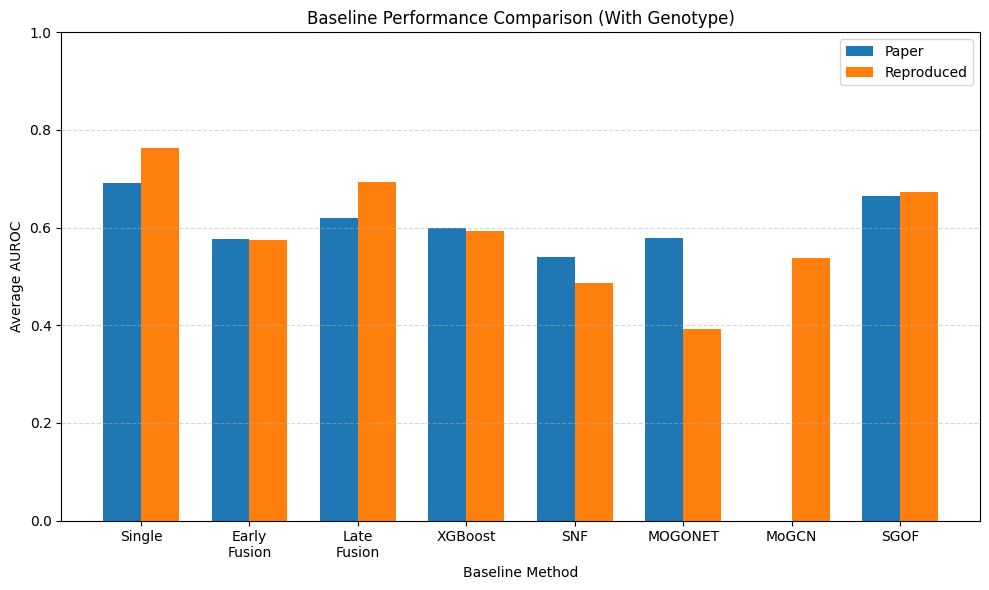

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Methods
methods = [
    "Single",
    "Early\nFusion",
    "Late\nFusion",
    "XGBoost",
    "SNF",
    "MOGONET",
    "MoGCN",
    "SGOF"
]

# Paper results (use np.nan if the paper didn't report a value)
paper = [0.692, 0.576, 0.619, 0.600, 0.539, 0.578, np.nan, 0.664]

# Your results (WITH genotype)
yours = [0.763, 0.574, 0.694, 0.594, 0.487, 0.392, 0.537, 0.673]

x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width/2, paper, width, label="Paper")
plt.bar(x + width/2, yours, width, label="Reproduced")

plt.xticks(x, methods)
plt.ylabel("Average AUROC")
plt.xlabel("Baseline Method")
plt.title("Baseline Performance Comparison (With Genotype)")
plt.ylim(0, 1)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

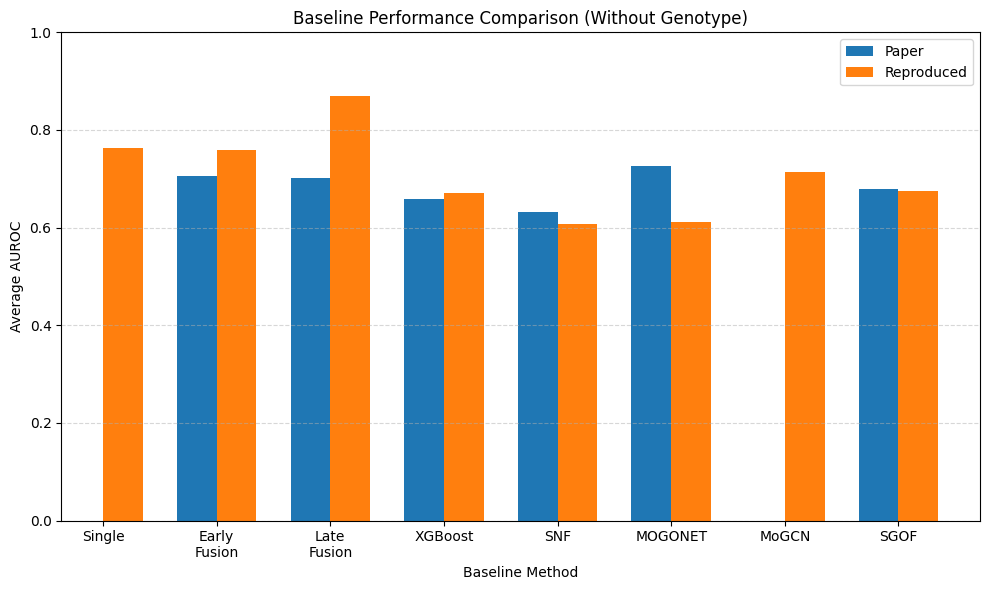

In [ ]:
paper_without = [np.nan, 0.706, 0.702, 0.659, 0.632, 0.727, np.nan, 0.679]

yours_without = [0.763, 0.758, 0.869, 0.670, 0.607, 0.611, 0.714, 0.676]

x = np.arange(len(methods))

plt.figure(figsize=(10,6))

plt.bar(x - width/2, paper_without, width, label="Paper")
plt.bar(x + width/2, yours_without, width, label="Reproduced")

plt.xticks(x, methods)
plt.ylabel("Average AUROC")
plt.xlabel("Baseline Method")
plt.title("Baseline Performance Comparison (Without Genotype)")
plt.ylim(0, 1)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### ROC Curve Comparison

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors # Potentially needed for SNF, added for completeness
from sklearn.metrics.pairwise import cosine_similarity # Needed for build_knn_graph
from scipy.spatial.distance import cdist # Needed for snf_similarity_kernel
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import pandas as pd # Added pandas import

# Define DATA_DIR if it's not already in the global scope (for self-containment)
if 'DATA_DIR' not in globals():
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/Data_Sairi'

# --- Re-defining dependencies from previous cells to make this cell self-contained ---
# From mUmRkasPJyOa
def load_omic(path, feature_col):
    df = pd.read_csv(path).set_index(feature_col).T
    df.index = df.index.astype(str)
    return df

condition = pd.read_csv(os.path.join(DATA_DIR, 'Patient_condition.csv'))
condition['ID'] = condition['ID'].astype(str)
condition = condition.set_index('ID')
y_series = (condition['RES'] == 'RES').astype(int)

geno = load_omic(os.path.join(DATA_DIR, 'Genotype_input.csv'), 'SNP')
expr = load_omic(os.path.join(DATA_DIR, 'Gene_expression_input.csv'), 'Gene')
meth = load_omic(os.path.join(DATA_DIR, 'DNA_methylation_input.csv'), 'CpG_sites')

common_ids = geno.index.intersection(expr.index).intersection(meth.index).intersection(y_series.index)
common_ids = sorted(common_ids, key=lambda x: int(x))

geno, expr, meth = geno.loc[common_ids], expr.loc[common_ids], meth.loc[common_ids]
y = y_series.loc[common_ids].values

modalities = {'genotype': geno.values.astype(np.float32),
              'expression': expr.values.astype(np.float32),
              'methylation': meth.values.astype(np.float32)}

modalities_no_genotype = {'expression': modalities['expression'],
                           'methylation': modalities['methylation']}
# --- End of re-defined dependencies ---


# Define method_names here so it's available for ROC curve generation
method_names = ['single_best', 'early_fusion', 'late_fusion', 'early_fusion_xgb', 'snf', 'mogonet', 'mogcn', 'sgof']

# --- Dependencies from previous cells for model evaluation functions ---

def preprocess_fold(X_train, X_test, y_train, k_features=200):
    col_means = np.nanmean(X_train, axis=0)
    X_train = np.where(np.isnan(X_train), col_means, X_train)
    X_test = np.where(np.isnan(X_test), col_means, X_test)

    f_scores, _ = f_classif(X_train, y_train)
    f_scores = np.nan_to_num(f_scores)
    top_idx = np.argsort(f_scores)[-k_features:]
    X_train, X_test = X_train[:, top_idx], X_test[:, top_idx]

    scaler = StandardScaler().fit(X_train)
    return scaler.transform(X_train), scaler.transform(X_test)

def eval_single_layer(X, y, train_idx, test_idx, k_features=200):
    Xtr, Xte = preprocess_fold(X[train_idx], X[test_idx], y[train_idx], k_features)
    clf = LogisticRegression(max_iter=2000, C=1.0).fit(Xtr, y[train_idx])
    return clf.predict_proba(Xte)[:, 1]

def eval_early_fusion(modalities, y, train_idx, test_idx, k_features=200):
    Xtr_all, Xte_all = [], []
    for X in modalities.values():
        Xtr, Xte = preprocess_fold(X[train_idx], X[test_idx], y[train_idx], k_features)
        Xtr_all.append(Xtr); Xte_all.append(Xte)
    Xtr_all, Xte_all = np.hstack(Xtr_all), np.hstack(Xte_all)
    clf = LogisticRegression(max_iter=2000, C=1.0).fit(Xtr_all, y[train_idx])
    return clf.predict_proba(Xte_all)[:, 1]

def eval_late_fusion(modalities, y, train_idx, test_idx, k_features=200):
    all_probs = [eval_single_layer(X, y, train_idx, test_idx, k_features) for X in modalities.values()]
    return np.mean(all_probs, axis=0)

def eval_early_fusion_xgb(modalities, y, train_idx, test_idx, k_features=200):
    Xtr_all, Xte_all = [], []
    for X in modalities.values():
        Xtr, Xte = preprocess_fold(X[train_idx], X[test_idx], y[train_idx], k_features)
        Xtr_all.append(Xtr); Xte_all.append(Xte)
    Xtr_all, Xte_all = np.hstack(Xtr_all), np.hstack(Xte_all)
    clf = XGBClassifier(n_estimators=100, max_depth=2, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.5, eval_metric='logloss', random_state=0)
    clf.fit(Xtr_all, y[train_idx])
    return clf.predict_proba(Xte_all)[:, 1]

def build_knn_graph(X, k=10):
    k = min(k, X.shape[0] - 1)
    S = cosine_similarity(X)
    np.fill_diagonal(S, 0)
    n = len(S)
    A = np.zeros_like(S)
    for i in range(n):
        nbrs = np.argsort(S[i])[-k:]
        A[i, nbrs] = S[i, nbrs]
    A = np.maximum(A, A.T)
    return A

def normalize_adj(A):
    A_hat = A + np.eye(A.shape[0])
    D = np.diag(1.0 / np.sqrt(A_hat.sum(1)))
    return D @ A_hat @ D

class GraphConv(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=True)

    def forward(self, X, A):
        return A @ self.W(X)

class GCNEncoder(nn.Module):
    def __init__(self, in_dim,
                 hidden1=200,
                 hidden2=200,
                 out_dim=100,
                 dropout=0.5):
        super().__init__()

        self.gc1 = GraphConv(in_dim, hidden1)
        self.gc2 = GraphConv(hidden1, hidden2)
        self.gc3 = GraphConv(hidden2, out_dim)

        self.dropout = dropout

    def forward(self, X, A):

        X = F.leaky_relu(self.gc1(X, A), 0.25)
        X = F.dropout(X, self.dropout, training=self.training)

        X = F.leaky_relu(self.gc2(X, A), 0.25)
        X = F.dropout(X, self.dropout, training=self.training)

        X = F.leaky_relu(self.gc3(X, A), 0.25)

        return X

class ModalityModel(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.encoder = GCNEncoder(in_dim)
        self.head = nn.Linear(100, 2)

    def forward(self, X, A_norm):
        return self.head(self.encoder(X, A_norm))

def train_modality_model_masked(X_all, A_norm, y_labeled, train_positions, epochs=100, lr=0.005):
    model = ModalityModel(X_all.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    X_t = torch.tensor(X_all, dtype=torch.float32)
    A_t = torch.tensor(A_norm, dtype=torch.float32)
    y_t = torch.tensor(y_labeled, dtype=torch.long)
    train_pos_t = torch.tensor(train_positions, dtype=torch.long)

    for _ in range(epochs):
        opt.zero_grad()
        logits_all = model(X_t, A_t)
        loss = F.cross_entropy(logits_all[train_pos_t], y_t)
        loss.backward()
        opt.step()
    return model

def train_modality_model_masked_ensemble(X_all, A_norm, y_labeled, train_positions,
                                          n_runs=3, epochs=200, lr=0.005):
    all_logits = []
    X_t = torch.tensor(X_all, dtype=torch.float32)
    A_t = torch.tensor(A_norm, dtype=torch.float32)
    for seed in range(n_runs):
        torch.manual_seed(seed)
        model = train_modality_model_masked(X_all, A_norm, y_labeled, train_positions, epochs=epochs, lr=lr)
        with torch.no_grad():
            all_logits.append(model(X_t, A_t))
    return torch.stack(all_logits).mean(dim=0)

def eval_sgof(modalities, y, train_idx, test_idx, k_features=200, n_runs=3, verbose=False):
    inner_train_idx, inner_val_idx = train_test_split(
        train_idx, test_size=0.25, stratify=y[train_idx], random_state=0
    )

    weights = {}
    test_logits = {}

    for name, X in modalities.items():
        X_in_tr, X_in_val = preprocess_fold(X[inner_train_idx], X[inner_val_idx], y[inner_train_idx], k_features)
        X_inner_all = np.vstack([X_in_tr, X_in_val])
        n_inner_train = X_in_tr.shape[0]
        A_inner_all = normalize_adj(build_knn_graph(X_inner_all, k=10))

        inner_logits = train_modality_model_masked_ensemble(
            X_inner_all, A_inner_all, y[inner_train_idx],
            train_positions=np.arange(n_inner_train), n_runs=n_runs
        )
        val_probs = F.softmax(inner_logits[n_inner_train:], dim=1)[:, 1].numpy()
        a_m = roc_auc_score(y[inner_val_idx], val_probs)
        weights[name] = max(a_m - 0.5, 0)

        Xtr_full, Xte = preprocess_fold(X[train_idx], X[test_idx], y[train_idx], k_features)
        X_full_all = np.vstack([Xtr_full, Xte])
        n_tr = Xtr_full.shape[0]
        A_full_all = normalize_adj(build_knn_graph(X_full_all, k=10))

        final_logits = train_modality_model_masked_ensemble(
            X_full_all, A_full_all, y[train_idx],
            train_positions=np.arange(n_tr), n_runs=n_runs
        )
        test_logits[name] = final_logits[n_tr:]

    total_s = sum(weights.values())
    if total_s == 0:
        weights = {k: 1/len(weights) for k in weights}
    else:
        weights = {k: v/total_s for k, v in weights.items()}

    normalized_logits = {name: test_logits[name] / (test_logits[name].std().item() + 1e-6) for name in modalities}
    fused_logits = sum(weights[name] * normalized_logits[name] for name in modalities)
    fused_probs = F.softmax(fused_logits, dim=1)[:, 1].detach().numpy()

    return fused_probs, weights

def snf_similarity_kernel(X, k=10, mu=0.5):
    dist = cdist(X, X, metric='euclidean')
    knn_dist = np.sort(dist, axis=1)[:, 1:k+1]
    eps = knn_dist.mean(axis=1) + 1e-6
    sigma = mu * (eps[:, None] + eps[None, :]) / 2 + dist / 3 + 1e-6
    W = np.exp(-dist**2 / (2 * sigma**2))
    np.fill_diagonal(W, 0)
    return W

def snf_normalize(W):
    d = W.sum(axis=1, keepdims=True)
    d[d == 0] = 1e-6
    return W / d

def snf_knn_sparsify(W, k=10):
    S = np.zeros_like(W)
    for i in range(W.shape[0]):
        idx = np.argsort(-W[i])[:k]
        S[i, idx] = W[i, idx]
    return snf_normalize(S)

def similarity_network_fusion(modality_sims, k=10, t=20, mu=0.5):
    Ps = [snf_normalize(W) for W in modality_sims]
    Ss = [snf_knn_sparsify(W, k) for W in modality_sims]
    m = len(Ps)
    for _ in range(t):
        new_Ps = []
        for v in range(m):
            avg_other = sum(Ps[u] for u in range(m) if u != v) / (m - 1)
            new_Ps.append(snf_normalize(Ss[v] @ avg_other @ Ss[v].T))
        Ps = new_Ps
    return sum(Ps) / m

def label_propagation(W, y_train, train_positions, test_positions, alpha=0.9, n_iter=50):
    n = W.shape[0]
    d = W.sum(axis=1); d[d == 0] = 1e-6
    S = np.diag(1.0/np.sqrt(d)) @ W @ np.diag(1.0/np.sqrt(d))

    Y = np.zeros((n, 2))
    for pos, label in zip(train_positions, y_train):
        Y[pos, label] = 1.0

    F_mat = Y.copy()
    for _ in range(n_iter):
        F_mat = alpha * (S @ F_mat) + (1 - alpha) * Y

    probs = F_mat[test_positions, 1] / (F_mat[test_positions].sum(axis=1) + 1e-6)
    return probs

def eval_snf(modalities, y, train_idx, test_idx, k_features=200):
    n_tr = len(train_idx)
    sims = []
    for X in modalities.values():
        Xtr, Xte = preprocess_fold(X[train_idx], X[test_idx], y[train_idx], k_features)
        sims.append(snf_similarity_kernel(np.vstack([Xtr, Xte]), k=10))
    W_fused = similarity_network_fusion(sims, k=10, t=20)
    return label_propagation(W_fused, y[train_idx], np.arange(n_tr), np.arange(n_tr, n_tr + len(test_idx)))

class VCDN(nn.Module):

    def __init__(self, n_modalities, n_classes=2):
        super().__init__()
        self.n_classes = n_classes
        self.net = nn.Sequential(
            nn.Linear(n_classes ** n_modalities, n_classes ** n_modalities),
            nn.LeakyReLU(0.25),
            nn.Linear(n_classes ** n_modalities, n_classes)
        )
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, logits_list):
        probs = [torch.sigmoid(x) for x in logits_list]
        x = probs[0]
        for p in probs[1:]:
            x = torch.einsum("bi,bj->bij", x, p).reshape(x.shape[0], -1)
        return self.net(x)

def eval_mogonet(modalities, y, train_idx, test_idx, k_features=200,
                 pretrain_epochs=200,
                 joint_epochs=50,
                 lr=0.005,
                 early_stopping_patience=10):

    n_tr = len(train_idx)
    models = {}
    graphs = {}
    X_alls = {}

    for name, X in modalities.items():
        Xtr, Xte = preprocess_fold(X[train_idx], X[test_idx], y[train_idx], k_features)
        X_all = np.vstack([Xtr, Xte])
        A = normalize_adj(build_knn_graph(X_all, k=10))
        graphs[name] = torch.tensor(A, dtype=torch.float32)
        X_alls[name] = torch.tensor(X_all, dtype=torch.float32)
        model = train_modality_model_masked(
            X_all=X_all, A_norm=A, y_labeled=y[train_idx],
            train_positions=np.arange(n_tr), epochs=pretrain_epochs, lr=lr
        )
        models[name] = model

    inner_train_fold_idx, inner_val_fold_idx = train_test_split(
        np.arange(n_tr), test_size=0.2, stratify=y[train_idx], random_state=42
    )

    y_t = torch.tensor(y[train_idx], dtype=torch.long)

    vcdn = VCDN(n_modalities=len(modalities))

    params = list(vcdn.parameters())
    for model in models.values():
        params += list(model.parameters())

    optimizer = torch.optim.Adam(params, lr=lr, weight_decay=1e-4)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_vcdn_state = None
    best_models_states = {name: None for name in modalities}

    for epoch in range(joint_epochs):
        optimizer.zero_grad()
        logits_list = []
        for name in modalities:
            logits = models[name](X_alls[name], graphs[name])
            logits_list.append(logits)
        fused_logits = vcdn(logits_list)

        train_loss = F.cross_entropy(
            fused_logits[inner_train_fold_idx], y_t[inner_train_fold_idx]
        )
        for logits in logits_list:
            train_loss += F.cross_entropy(
                logits[inner_train_fold_idx], y_t[inner_train_fold_idx]
            )

        train_loss.backward()
        optimizer.step()

        with torch.no_grad():
            val_logits_list = []
            for name in modalities:
                val_logits_list.append(models[name](X_alls[name], graphs[name]))
            val_fused_logits = vcdn(val_logits_list)

            val_loss = F.cross_entropy(
                val_fused_logits[inner_val_fold_idx], y_t[inner_val_fold_idx]
            )
            for logits in val_logits_list:
                val_loss += F.cross_entropy(
                    logits[inner_val_fold_idx], y_t[inner_val_fold_idx]
                )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_vcdn_state = vcdn.state_dict()
            for name, model in models.items():
                best_models_states[name] = model.state_dict()
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= early_stopping_patience:
            break

    if best_vcdn_state:
        vcdn.load_state_dict(best_vcdn_state)
    for name, model in models.items():
        if best_models_states[name]:
            model.load_state_dict(best_models_states[name])

    with torch.no_grad():
        logits_list = []
        for name in modalities:
            logits = models[name](X_alls[name], graphs[name])
            logits_list.append(logits)
        fused_logits = vcdn(logits_list)
        probs = torch.softmax(fused_logits, dim=1)[:, 1].numpy()

    return probs[n_tr:]

class SimpleAutoencoder(nn.Module):
    def __init__(self, in_dim, latent=32):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(in_dim, 64), nn.ReLU(), nn.Linear(64, latent))
        self.dec = nn.Sequential(nn.Linear(latent, 64), nn.ReLU(), nn.Linear(64, in_dim))

    def forward(self, x):
        z = self.enc(x)
        return self.dec(z), z

def train_autoencoder(X, epochs=150, lr=0.001):
    model = SimpleAutoencoder(X.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    X_t = torch.tensor(X, dtype=torch.float32)
    for _ in range(epochs):
        opt.zero_grad()
        recon, _ = model(X_t)
        loss = F.mse_loss(recon, X_t)
        loss.backward()
        opt.step()
    with torch.no_grad():
        _, z = model(X_t)
    return z.numpy()

def eval_mogcn(modalities, y, train_idx, test_idx, k_features=200):
    n_tr = len(train_idx)
    latents = []
    for X in modalities.values():
        Xtr, Xte = preprocess_fold(X[train_idx], X[test_idx], y[train_idx], k_features)
        latents.append(train_autoencoder(np.vstack([Xtr, Xte])))

    sims = [snf_similarity_kernel(z, k=10) for z in latents]
    A_fused = normalize_adj(similarity_network_fusion(sims, k=10, t=20))

    X_concat = np.hstack(latents)
    X_t = torch.tensor(X_concat, dtype=torch.float32)
    A_t = torch.tensor(A_fused, dtype=torch.float32)
    y_t = torch.tensor(y[train_idx], dtype=torch.long)
    train_pos = torch.arange(n_tr)

    model = ModalityModel(X_concat.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
    for _ in range(150):
        opt.zero_grad()
        loss = F.cross_entropy(model(X_t, A_t)[train_pos], y_t)
        loss.backward()
        opt.step()

    with torch.no_grad():
        probs = F.softmax(model(X_t, A_t), dim=1)[:, 1].numpy()
    return probs[n_tr:]

# --- End of dependencies ---

# Re-define run_all_methods to return probabilities instead of just AUROC
def run_all_methods_for_roc(mods, y, train_idx, test_idx, k_features=200):
    predictions = {}
    # For 'single_best', we explicitly use 'methylation' as it was identified as the best performing single modality
    predictions['single_best'] = eval_single_layer(mods['methylation'], y, train_idx, test_idx, k_features)
    predictions['early_fusion'] = eval_early_fusion(mods, y, train_idx, test_idx, k_features)
    predictions['late_fusion'] = eval_late_fusion(mods, y, train_idx, test_idx, k_features)
    predictions['early_fusion_xgb'] = eval_early_fusion_xgb(mods, y, train_idx, test_idx, k_features)
    predictions['snf'] = eval_snf(mods, y, train_idx, test_idx, k_features)
    predictions['mogonet'] = eval_mogonet(mods, y, train_idx, test_idx, k_features)
    predictions['mogcn'] = eval_mogcn(mods, y, train_idx, test_idx, k_features)
    probs_sgof, _ = eval_sgof(mods, y, train_idx, test_idx, k_features) # SGOF returns probs and weights
    predictions['sgof'] = probs_sgof
    return predictions, y[test_idx]

# Initialize storage for all true labels and predicted probabilities
# This will store lists of arrays, which will be concatenated later
all_y_true_with = {m: [] for m in method_names}
all_y_pred_with = {m: [] for m in method_names}
all_y_true_without = {m: [] for m in method_names}
all_y_pred_without = {m: [] for m in method_names}

# Re-run the cross-validation loop to collect probabilities
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
print("Collecting predictions across all folds...")
for fold_i, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(y)), y)):
    # With Genotype
    predictions_with, y_true_fold_with = run_all_methods_for_roc(modalities, y, train_idx, test_idx)
    for m in method_names:
        all_y_true_with[m].append(y_true_fold_with)
        all_y_pred_with[m].append(predictions_with[m])

    # Without Genotype
    predictions_without, y_true_fold_without = run_all_methods_for_roc(modalities_no_genotype, y, train_idx, test_idx)
    for m in method_names:
        all_y_true_without[m].append(y_true_fold_without)
        all_y_pred_without[m].append(predictions_without[m])
print("Prediction collection complete.")

# --- Plotting Function ---
def plot_roc_curves(y_true_dict, y_pred_dict, title_suffix, output_dir_name="roc_curves"):
    plt.figure(figsize=(10, 8))
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUROC = 0.50)')

    # Ensure output directory exists
    output_path = os.path.join("./", output_dir_name)
    os.makedirs(output_path, exist_ok=True)

    for method_name in method_names:
        y_true_combined = np.concatenate(y_true_dict[method_name])
        y_pred_combined = np.concatenate(y_pred_dict[method_name])

        if len(np.unique(y_true_combined)) > 1: # Ensure there are at least two classes to compute ROC
            fpr, tpr, _ = roc_curve(y_true_combined, y_pred_combined)
            roc_auc = roc_auc_score(y_true_combined, y_pred_combined)
            plt.plot(fpr, tpr, label=f'{method_name.replace("_", " ").title()} (AUROC = {roc_auc:.2f})')
        else:
            print(f"Warning: Not enough unique classes in y_true for {method_name} to compute ROC curve.")

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve Comparison {title_suffix}')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    # Save figures
    png_filename = os.path.join(output_path, f'roc_curve_{title_suffix.replace(" ", "_").lower()}.png')
    pdf_filename = os.path.join(output_path, f'roc_curve_{title_suffix.replace(" ", "_").lower()}.pdf')

    plt.savefig(png_filename, dpi=300)
    print(f"Saved PNG: {png_filename}")
    plt.savefig(pdf_filename, dpi=300)
    print(f"Saved PDF: {pdf_filename}")
    plt.close()

# Generate ROC curves for 'With Genotype' models
plot_roc_curves(all_y_true_with, all_y_pred_with, "(With Genotype)", output_dir_name="roc_curves")

# Generate ROC curves for 'Without Genotype' models
plot_roc_curves(all_y_true_without, all_y_pred_without, "(Without Genotype)", output_dir_name="roc_curves")

print("All ROC curve figures generated successfully!")

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 44098 232948] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Prediction collection complete.
Saved PNG: ./roc_curves/roc_curve_(with_genotype).png
Saved PDF: ./roc_curves/roc_curve_(with_genotype).pdf
Saved PNG: ./roc_curves/roc_curve_(without_genotype).png
Saved PDF: ./roc_curves/roc_curve_(without_genotype).pdf
All ROC curve figures generated successfully!


In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np
import os

# Ensure method_names is available (copied from the previous cell for self-containment)
method_names = ['single_best', 'early_fusion', 'late_fusion', 'early_fusion_xgb', 'snf', 'mogonet', 'mogcn', 'sgof']

# --- Plotting Function for PR Curves ---
def plot_pr_curves(y_true_dict, y_pred_dict, title_suffix, output_dir_name="pr_curves"):
    plt.figure(figsize=(10, 8))
    plt.plot([0, 1], [0, 0.5], 'k--', label='No-skill classifier (AP = 0.50)') # Baseline for balanced classes

    # Ensure output directory exists
    output_path = os.path.join("./", output_dir_name)
    os.makedirs(output_path, exist_ok=True)

    for method_name in method_names:
        y_true_combined = np.concatenate(y_true_dict[method_name])
        y_pred_combined = np.concatenate(y_pred_dict[method_name])

        # Check if there are at least two unique classes to compute PR curve
        if len(np.unique(y_true_combined)) > 1:
            precision, recall, _ = precision_recall_curve(y_true_combined, y_pred_combined)
            average_precision = average_precision_score(y_true_combined, y_pred_combined)
            plt.plot(recall, precision, label=f'{method_name.replace("_", " ").title()} (AP = {average_precision:.2f})')
        else:
            print(f"Warning: Not enough unique classes in y_true for {method_name} to compute PR curve.")

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve Comparison {title_suffix}')
    plt.legend(loc='lower left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.ylim([0.0, 1.05])
    plt.xlim([0.0, 1.0])
    plt.tight_layout()

    # Save figures
    png_filename = os.path.join(output_path, f'pr_curve_{title_suffix.replace(" ", "_").lower()}.png')
    pdf_filename = os.path.join(output_path, f'pr_curve_{title_suffix.replace(" ", "_").lower()}.pdf')

    plt.savefig(png_filename, dpi=300)
    print(f"Saved PNG: {png_filename}")
    plt.savefig(pdf_filename, dpi=300)
    print(f"Saved PDF: {pdf_filename}")
    plt.close()

# Generate PR curves for 'With Genotype' models
print("Generating PR curves for models with genotype data...")
plot_pr_curves(all_y_true_with, all_y_pred_with, "(With Genotype)", output_dir_name="pr_curves")

# Generate PR curves for 'Without Genotype' models
print("Generating PR curves for models without genotype data...")
plot_pr_curves(all_y_true_without, all_y_pred_without, "(Without Genotype)", output_dir_name="pr_curves")

print("All PR curve figures generated successfully!")

Generating PR curves for models with genotype data...
Saved PNG: ./pr_curves/pr_curve_(with_genotype).png
Saved PDF: ./pr_curves/pr_curve_(with_genotype).pdf
Generating PR curves for models without genotype data...
Saved PNG: ./pr_curves/pr_curve_(without_genotype).png
Saved PDF: ./pr_curves/pr_curve_(without_genotype).pdf
All PR curve figures generated successfully!


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix, roc_auc_score

# 1. Identify the best-performing classifier
# Calculate mean AUROC for each method with genotype from collected probabilities
mean_auroc_with = {}
for m in method_names:
    y_true_combined = np.concatenate(all_y_true_with[m])
    y_pred_combined = np.concatenate(all_y_pred_with[m])
    # Ensure there are at least two classes to compute ROC
    if len(np.unique(y_true_combined)) > 1:
        mean_auroc_with[m] = roc_auc_score(y_true_combined, y_pred_combined)
    else:
        mean_auroc_with[m] = 0.5 # Assign a baseline if ROC cannot be computed

# Calculate mean AUROC for each method without genotype from collected probabilities
mean_auroc_without = {}
for m in method_names:
    y_true_combined = np.concatenate(all_y_true_without[m])
    y_pred_combined = np.concatenate(all_y_pred_without[m])
    # Ensure there are at least two classes to compute ROC
    if len(np.unique(y_true_combined)) > 1:
        mean_auroc_without[m] = roc_auc_score(y_true_combined, y_pred_combined)
    else:
        mean_auroc_without[m] = 0.5 # Assign a baseline if ROC cannot be computed

# Find the best method and its AUROC with genotype
best_method_with = max(mean_auroc_with, key=mean_auroc_with.get)
best_auroc_with = mean_auroc_with[best_method_with]

# Find the best method and its AUROC without genotype
best_method_without = max(mean_auroc_without, key=mean_auroc_without.get)
best_auroc_without = mean_auroc_without[best_method_without]

print(f"Best classifier with genotype: {best_method_with.replace('_', ' ').title()} (AUROC: {best_auroc_with:.3f})")
print(f"Best classifier without genotype: {best_method_without.replace('_', ' ').title()} (AUROC: {best_auroc_without:.3f})")

# Overall best classifier
if best_auroc_with > best_auroc_without:
    overall_best_method = best_method_with
    overall_best_auroc = best_auroc_with
    overall_best_genotype_status = "with genotype"
    y_true_combined = np.concatenate(all_y_true_with[overall_best_method])
    y_pred_probs_combined = np.concatenate(all_y_pred_with[overall_best_method])
else:
    overall_best_method = best_method_without
    overall_best_auroc = best_auroc_without
    overall_best_genotype_status = "without genotype"
    y_true_combined = np.concatenate(all_y_true_without[overall_best_method])
    y_pred_probs_combined = np.concatenate(all_y_pred_without[overall_best_method])

print(f"\nOverall best-performing classifier is {overall_best_method.replace('_', ' ').title()} {overall_best_genotype_status} (Average AUROC: {overall_best_auroc:.3f})")

# Convert probabilities to binary predictions (threshold = 0.5)
y_pred_labels_combined = (y_pred_probs_combined > 0.5).astype(int)

# 2. Generate Confusion Matrix
cm = confusion_matrix(y_true_combined, y_pred_labels_combined)

# Create output directory
output_dir = "./confusion_matrices"
os.makedirs(output_dir, exist_ok=True)

def plot_confusion_matrix(cm, title, output_filename_base):
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        linewidths=.5,
        linecolor='black',
        xticklabels=['Predicted 0', 'Predicted 1'],
        yticklabels=['Actual 0', 'Actual 1']
    )
    plt.title(f'Confusion Matrix: {title} (Counts)')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{output_filename_base}_counts.png'), dpi=300)
    plt.savefig(os.path.join(output_dir, f'{output_filename_base}_counts.pdf'), dpi=300)
    print(f"Saved {output_filename_base}_counts.png and .pdf")
    plt.close()

    # Normalized confusion matrix (percentages)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt='.2%',
        cmap='Blues',
        cbar=False,
        linewidths=.5,
        linecolor='black',
        xticklabels=['Predicted 0', 'Predicted 1'],
        yticklabels=['Actual 0', 'Actual 1']
    )
    plt.title(f'Normalized Confusion Matrix: {title} (Percentages)')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{output_filename_base}_percentages.png'), dpi=300)
    plt.savefig(os.path.join(output_dir, f'{output_filename_base}_percentages.pdf'), dpi=300)
    print(f"Saved {output_filename_base}_percentages.png and .pdf")
    plt.close()

# Plot for the overall best performing classifier
plot_title = f"{overall_best_method.replace('_', ' ').title()} {overall_best_genotype_status}"
output_file_base = f"cm_{overall_best_method.replace('_', '_').lower()}_{overall_best_genotype_status.replace(' ', '_')}"
plot_confusion_matrix(cm, plot_title, output_file_base)

print("Confusion matrices generated successfully!")

Best classifier with genotype: Single Best (AUROC: 0.766)
Best classifier without genotype: Late Fusion (AUROC: 0.817)

Overall best-performing classifier is Late Fusion without genotype (Average AUROC: 0.817)
Saved cm_late_fusion_without_genotype_counts.png and .pdf
Saved cm_late_fusion_without_genotype_percentages.png and .pdf
Confusion matrices generated successfully!


--- Fold 10 --- (MOGONET - k_features=200, epochs=200, lr=0.05 )

=== WITH genotype ===
single_best: 0.763 (+/- 0.131)
early_fusion: 0.574 (+/- 0.126)
late_fusion: 0.694 (+/- 0.096)
early_fusion_xgb: 0.465 (+/- 0.125)
snf: 0.487 (+/- 0.108)
mogonet: 0.419 (+/- 0.194)
mogcn: 0.587 (+/- 0.124)
sgof: 0.668 (+/- 0.115)

=== WITHOUT genotype ===
single_best: 0.763 (+/- 0.131)
early_fusion: 0.758 (+/- 0.124)
late_fusion: 0.869 (+/- 0.087)
early_fusion_xgb: 0.658 (+/- 0.121)
snf: 0.607 (+/- 0.168)
mogonet: 0.629 (+/- 0.156)
mogcn: 0.642 (+/- 0.156)
sgof: 0.697 (+/- 0.121)

SGOF weights WITH genotype: {'genotype': np.float64(0.08975690975690973), 'expression': np.float64(0.5293299023241844), 'methylation': np.float64(0.3809131879189058)}
SGOF weights WITHOUT genotype: {'expression': np.float64(0.5754392557133053), 'methylation': np.float64(0.4245607442866947)}

--- Fold 10 ---  All models. have k_features=200, epochs=200, lr=0.05

=== WITH genotype ===
single_best: 0.763 (+/- 0.131)
early_fusion: 0.574 (+/- 0.126)
late_fusion: 0.694 (+/- 0.096)
early_fusion_xgb: 0.465 (+/- 0.125)
snf: 0.487 (+/- 0.108)
mogonet: 0.419 (+/- 0.194)
mogcn: 0.450 (+/- 0.146)
sgof: 0.668 (+/- 0.146)

=== WITHOUT genotype ===
single_best: 0.763 (+/- 0.131)
early_fusion: 0.758 (+/- 0.124)
late_fusion: 0.869 (+/- 0.087)
early_fusion_xgb: 0.658 (+/- 0.121)
snf: 0.607 (+/- 0.168)
mogonet: 0.629 (+/- 0.156)
mogcn: 0.662 (+/- 0.109)
sgof: 0.698 (+/- 0.140)

SGOF weights WITH genotype: {'genotype': np.float64(0.07156955380577426), 'expression': np.float64(0.537029315290893), 'methylation': np.float64(0.3914011309033328)}
SGOF weights WITHOUT genotype: {'expression': np.float64(0.5725370066585584), 'methylation': np.float64(0.4274629933414416)}

--- Fold 10 --- MoGCN (X, epochs=100, lr=0.005) | mogonet(modalities, y, train_idx, test_idx, k_features=200, epochs=200, lr=0.05)|

=== WITH genotype ===
single_best: 0.763 (+/- 0.131)
early_fusion: 0.574 (+/- 0.126)
late_fusion: 0.694 (+/- 0.096)
early_fusion_xgb: 0.465 (+/- 0.125)
snf: 0.487 (+/- 0.108)
mogonet: 0.419 (+/- 0.194)
mogcn: 0.555 (+/- 0.138)
sgof: 0.668 (+/- 0.146)

=== WITHOUT genotype ===
single_best: 0.763 (+/- 0.131)
early_fusion: 0.758 (+/- 0.124)
late_fusion: 0.869 (+/- 0.087)
early_fusion_xgb: 0.658 (+/- 0.121)
snf: 0.607 (+/- 0.168)
mogonet: 0.629 (+/- 0.156)
mogcn: 0.665 (+/- 0.218)
sgof: 0.698 (+/- 0.140)

SGOF weights WITH genotype: {'genotype': np.float64(0.07156955380577426), 'expression': np.float64(0.537029315290893), 'methylation': np.float64(0.3914011309033328)}
SGOF weights WITHOUT genotype: {'expression': np.float64(0.5725370066585584), 'methylation': np.float64(0.4274629933414416)}

### System Architecture Diagram

In [4]:
import graphviz
import os

# Define the DOT graph content
dot_content = """digraph G {
    rankdir=TB;
    dpi=300; // Set DPI directly in DOT for PNG export
    node [shape=box, style="filled,rounded", fillcolor="#e0e0e0", fontname="Helvetica"];
    edge [fontname="Helvetica", color="#666666"];

    // Nodes
    subgraph cluster_inputs {
        label = "Multi-Omic Inputs";
        color = "#4CAF50";
        style = "filled,rounded";
        fillcolor = "#f0fdf0";

        A [label="Genotype"];
        B [label="Gene Expression"];
        C [label="DNA Methylation"];
    }

    subgraph cluster_preprocessing {
        label = "Cross-Validation Preprocessing";
        color = "#2196F3";
        style = "filled,rounded";
        fillcolor = "#e3f2fd";

        D [label="Patient Alignment"];
        E [label="Missing Value Imputation"];
        F [label="ANOVA Feature Selection"];
        G [label="Standardization"];
    }

    H [label="Patient Similarity Graph Construction", shape=cylinder, fillcolor="#FFF9C4"];

    subgraph cluster_single_models {
        label = "Single-Modality Models";
        color = "#FFC107";
        style = "filled,rounded";
        fillcolor = "#fffde7";

        I [label="Genotype Model"];
        J [label="Expression Model"];
        K [label="Methylation Model"];
    }

    L [label="Signal-Gated Omic Fusion (SGOF)", shape=octagon, fillcolor="#FFCDD2"];
    M [label="Final Antidepressant Response Prediction", shape=oval, fillcolor="#BBDEFB"];

    // Edges
    A -> D;
    B -> D;
    C -> D;

    D -> E;
    E -> F;
    F -> G;

    G -> H [label="Processed Data"];

    H -> I [label="Graph & Data"];
    H -> J [label="Graph & Data"];
    H -> K [label="Graph & Data"];

    I -> L [label="Logits"];
    J -> L [label="Logits"];
    K -> L [label="Logits"];

    L -> M [label="Fused Probabilities"];
}"""

# Create a Graphviz Source object
graph = graphviz.Source(dot_content)

# Define output file paths
output_dir = "./diagrams"
os.makedirs(output_dir, exist_ok=True)

png_path = os.path.join(output_dir, "system_architecture.png")
pdf_path = os.path.join(output_dir, "system_architecture.pdf")

# Render and save the diagram
print(f"Generating PNG to: {png_path}")
graph.render(filename=png_path.replace('.png', ''), format='png', cleanup=True)
print(f"Generating PDF to: {pdf_path}")
graph.render(filename=pdf_path.replace('.pdf', ''), format='pdf', cleanup=True)

print("Diagrams generated successfully!")

Generating PNG to: ./diagrams/system_architecture.png
Generating PDF to: ./diagrams/system_architecture.pdf
Diagrams generated successfully!


### Patient Similarity Graph Visualizations

In [7]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cdist # cdist is used by snf_similarity_kernel, not directly by build_knn_graph, but often imported together

# --- Re-defining dependencies from previous cells to make this cell self-contained ---
# Assuming DATA_DIR is accessible from previous execution or defined globally if needed
# If DATA_DIR is not defined, you might need to run the `from google.colab import drive` and `DATA_DIR = ...` cells.
# For now, let's try to assume DATA_DIR is available in the environment.

# Re-define load_omic function (from mUmRkasPJyOa)
def load_omic(path, feature_col):
    df = pd.read_csv(path).set_index(feature_col).T
    df.index = df.index.astype(str)
    return df

# Re-define modalities (from mUmRkasPJyOa)
# This section duplicates code from mUmRkasPJyOa. In a typical notebook workflow,
# you would simply run the preceding cells to ensure these are defined.
# However, to fix the NameError within this cell via `modify_cells`, it's necessary.

# If DATA_DIR is not defined yet, uncomment and set it:
# DATA_DIR = '/content/drive/MyDrive/Data_Sairi'

if 'DATA_DIR' not in globals():
    print("DATA_DIR is not defined. Please ensure the cell defining DATA_DIR is run.")
    # Attempt to use a common default path if not defined, for execution context
    DATA_DIR = '/content/drive/MyDrive/Data_Sairi'
    from google.colab import drive
    drive.mount('/content/drive')


condition = pd.read_csv(os.path.join(DATA_DIR, 'Patient_condition.csv'))
condition['ID'] = condition['ID'].astype(str)
condition = condition.set_index('ID')
y_series = (condition['RES'] == 'RES').astype(int)

geno = load_omic(os.path.join(DATA_DIR, 'Genotype_input.csv'), 'SNP')
expr = load_omic(os.path.join(DATA_DIR, 'Gene_expression_input.csv'), 'Gene')
meth = load_omic(os.path.join(DATA_DIR, 'DNA_methylation_input.csv'), 'CpG_sites')

common_ids = geno.index.intersection(expr.index).intersection(meth.index).intersection(y_series.index)
common_ids = sorted(common_ids, key=lambda x: int(x))

geno, expr, meth = geno.loc[common_ids], expr.loc[common_ids], meth.loc[common_ids]
y = y_series.loc[common_ids].values

modalities = {'genotype': geno.values.astype(np.float32),
              'expression': expr.values.astype(np.float32),
              'methylation': meth.values.astype(np.float32)}

# Re-define build_knn_graph (from DgyFbiqLFgZ4)
def build_knn_graph(X, k=10):
    """
    Build a symmetric weighted k-NN graph using cosine similarity.
    Matches the MOGONET paper more closely than a binary Euclidean graph.
    """
    k = min(k, X.shape[0] - 1)
    S = cosine_similarity(X)

    np.fill_diagonal(S, 0)

    n = len(S)
    A = np.zeros_like(S)

    for i in range(n):
        nbrs = np.argsort(S[i])[-k:]
        A[i, nbrs] = S[i, nbrs]

    # Symmetrize
    A = np.maximum(A, A.T)

    return A
# --- End of re-defined dependencies ---


# Create a directory for graph figures
figures_output_dir = "./graph_figures"
os.makedirs(figures_output_dir, exist_ok=True)

# Loop through each modality to build and visualize its graph
for name, X_data_original in modalities.items(): # Renamed X_data to X_data_original to avoid confusion
    print(f"Generating patient similarity graph for: {name}")

    # Impute NaN values before building graph for visualization
    X_data_imputed = X_data_original.copy() # Work on a copy to not modify original modalities data
    if np.isnan(X_data_imputed).any():
        print(f"  Warning: NaNs found in {name} data. Imputing with column means.")
        col_means = np.nanmean(X_data_imputed, axis=0)
        # Fill potential NaNs in col_means (e.g., if a whole column was NaN)
        col_means[np.isnan(col_means)] = 0 # Replace with 0 or a more appropriate value if context allows
        X_data_imputed = np.where(np.isnan(X_data_imputed), col_means, X_data_imputed)

    # Build the k-NN graph (adjacency matrix) using the existing function
    A = build_knn_graph(X_data_imputed, k=10)

    # Create a NetworkX graph from the adjacency matrix
    G = nx.from_numpy_array(A)

    plt.figure(figsize=(10, 10))
    pos = nx.spring_layout(G, k=0.5, iterations=50) # Use spring layout for better visualization of clusters

    # Draw the nodes (patients)
    # Nodes are patients, but individual labels for 111 nodes would be too cluttered.
    # We will convey this via the title and overall explanation.
    nx.draw_networkx_nodes(G, pos, node_size=50, node_color='skyblue', alpha=0.8)

    # Draw the edges (molecular similarity)
    # Edges represent molecular similarity. For clarity in a dense graph,
    # we use a consistent color and alpha, implying similarity strength.
    # Edge weights are implicitly handled by the graph structure.
    nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.3, edge_color='gray')

    plt.title(f'Patient Similarity Graph - {name.capitalize()} Modality (Nodes: Patients, Edges: Molecular Similarity)', fontsize=16)
    plt.axis('off') # Hide axes
    plt.tight_layout()

    # Save the figure as PNG
    png_filename = os.path.join(figures_output_dir, f'patient_similarity_graph_{name}.png')
    plt.savefig(png_filename, dpi=300)
    print(f"Saved PNG: {png_filename}")

    # Save the figure as PDF
    pdf_filename = os.path.join(figures_output_dir, f'patient_similarity_graph_{name}.pdf')
    plt.savefig(pdf_filename, dpi=300)
    print(f"Saved PDF: {pdf_filename}")

    plt.close() # Close the plot to free memory

print("All patient similarity graphs generated successfully!")

Generating patient similarity graph for: genotype
Saved PNG: ./graph_figures/patient_similarity_graph_genotype.png
Saved PDF: ./graph_figures/patient_similarity_graph_genotype.pdf
Generating patient similarity graph for: expression
Saved PNG: ./graph_figures/patient_similarity_graph_expression.png
Saved PDF: ./graph_figures/patient_similarity_graph_expression.pdf
Generating patient similarity graph for: methylation
Saved PNG: ./graph_figures/patient_similarity_graph_methylation.png
Saved PDF: ./graph_figures/patient_similarity_graph_methylation.pdf
All patient similarity graphs generated successfully!


### Alluvial Plots for Patient Class Progression

Alluvial plots are ideal for visualizing changes in patient classifications across multiple predictive models. Each 'stream' in the plot represents a patient, and its width is proportional to the number of patients. The plot shows how patients are classified (0 or 1) by one model, and then how those same patients are re-classified by subsequent models, highlighting transitions and stable classifications.

In [16]:
# Install pyalluvial for generating alluvial plots
!pip install pyalluvial


In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from pyalluvial import alluvial

# Helper function to get patient-level classifications for alluvial plots
# This aggregates predictions from all folds back to original patient IDs.
def get_patient_level_classifications(all_y_true_dict, all_y_pred_dict, method_names, y_overall, common_ids, skf_splitter):
    n_patients = len(y_overall)
    # Dictionary to store predictions, keyed by original patient index
    patient_data = {i: {'True_Label': y_overall[i]} for i in range(n_patients)}

    # Re-iterate through folds to correctly map predictions to original patient indices
    current_fold = 0
    for train_idx, test_idx in skf_splitter.split(np.zeros(n_patients), y_overall):
        for method_name in method_names:
            # Get predictions for the current method and fold
            y_pred_probs_fold = all_y_pred_dict[method_name][current_fold]
            y_pred_labels_fold = (y_pred_probs_fold > 0.5).astype(int)

            # Map these predictions back to the original patient indices
            for i, patient_original_idx in enumerate(test_idx):
                patient_data[patient_original_idx][method_name] = y_pred_labels_fold[i]
        current_fold += 1

    # Convert to a pandas DataFrame
    df_alluvial_patients = pd.DataFrame.from_dict(patient_data, orient='index')
    df_alluvial_patients.index.name = 'Patient_Original_Index'
    df_alluvial_patients['Patient_ID'] = [common_ids[i] for i in df_alluvial_patients.index]

    # Ensure model columns are of type string for alluvial plotting
    for m in method_names:
        df_alluvial_patients[m] = df_alluvial_patients[m].astype(str)

    # Reorder columns for clarity
    cols = ['Patient_ID', 'True_Label'] + method_names
    df_alluvial_patients = df_alluvial_patients[cols]

    return df_alluvial_patients


def plot_alluvial_diagram(df_alluvial, title_suffix, output_dir_name="alluvial_plots"):
    # Ensure output directory exists
    output_path = os.path.join("./", output_dir_name)
    os.makedirs(output_path, exist_ok=True)

    # Columns for the alluvial plot will be the model predictions
    alluvial_cols = method_names

    # Prepare data for alluvial plotting by adding a 'count' column for each patient
    df_plot_for_alluvial = df_alluvial.copy()
    df_plot_for_alluvial['count'] = 1 # Each row (patient) contributes 1 to the flow

    # Rename columns for better plot labels (e.g., 'early_fusion' -> 'Early Fusion')
    column_rename_map = {m: m.replace('_', ' ').title() for m in method_names}
    df_plot_for_alluvial = df_plot_for_alluvial.rename(columns=column_rename_map)
    display_cols_renamed = [column_rename_map[m] for m in method_names]

    # Group by the sequence of classifications across models and the True_Label for coloring
    df_grouped = df_plot_for_alluvial.groupby(display_cols_renamed + ['True_Label']).agg(count=('count', 'sum')).reset_index()

    fig, ax = plt.subplots(1, 1, figsize=(18, 10)) # Adjust figsize as needed for readability

    # Generate the alluvial plot
    alluvial(df_grouped,
             ax=ax,
             keys=display_cols_renamed, # Stages of the alluvial plot
             value='count',             # Column representing the flow quantity
             hue='True_Label',          # Column for coloring the streams
             linewidth=0,               # No lines around the streams
             edgecolors='gray',         # Minimal edge for distinction
             labels=True,
             title=f'Patient Class Progression {title_suffix}',
             cmap='Set1',               # 'Set1' or 'Paired' are good categorical colormaps
             alpha=0.7                  # Transparency for overlapping flows
            )

    ax.set_title(f'Patient Class Progression {title_suffix}', fontsize=16)
    plt.xlabel("Models", fontsize=14)
    plt.ylabel("Number of Patients", fontsize=14)
    plt.tight_layout()

    # Save figures
    png_filename = os.path.join(output_path, f'alluvial_plot_{title_suffix.replace(" ", "_").lower()}.png')
    pdf_filename = os.path.join(output_path, f'alluvial_plot_{title_suffix.replace(" ", "_").lower()}.pdf')

    plt.savefig(png_filename, dpi=300)
    print(f"Saved PNG: {png_filename}")
    plt.savefig(pdf_filename, dpi=300)
    print(f"Saved PDF: {pdf_filename}")
    plt.close()

Preparing alluvial data for models WITH genotype...
Generating alluvial plot for models WITH genotype...


TypeError: 'module' object is not callable

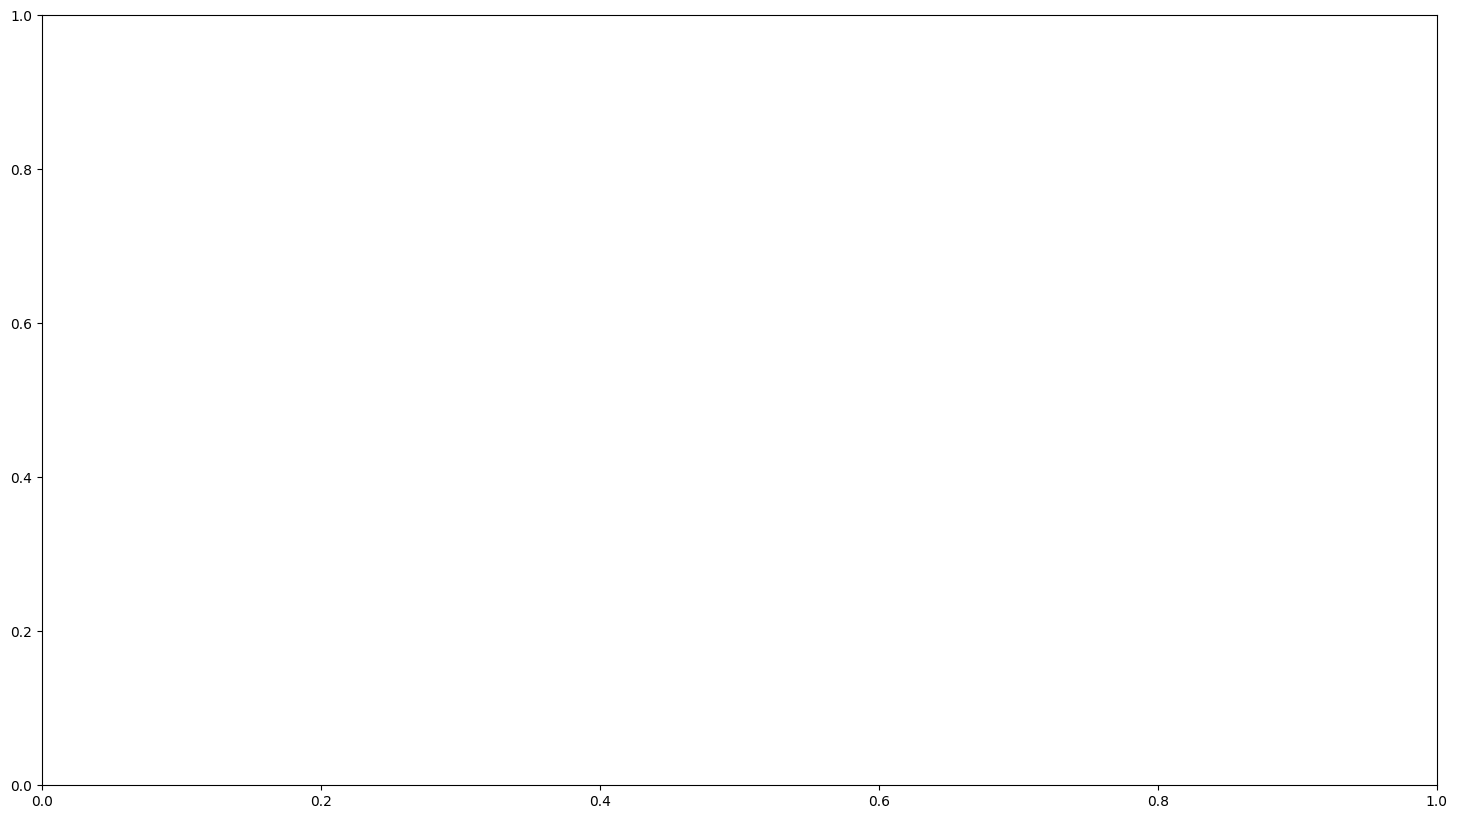

In [21]:
# 1. Prepare data for 'With Genotype' models
print("Preparing alluvial data for models WITH genotype...")
df_alluvial_with = get_patient_level_classifications(all_y_true_with, all_y_pred_with, method_names, y, common_ids, skf)

# 2. Generate and save the alluvial plot for 'With Genotype' models
print("Generating alluvial plot for models WITH genotype...")
plot_alluvial_diagram(df_alluvial_with, "(With Genotype)")

print("Alluvial plot generation for 'With Genotype' complete!")

Preparing alluvial data for models WITHOUT genotype...
Generating alluvial plot for models WITHOUT genotype...


TypeError: 'module' object is not callable

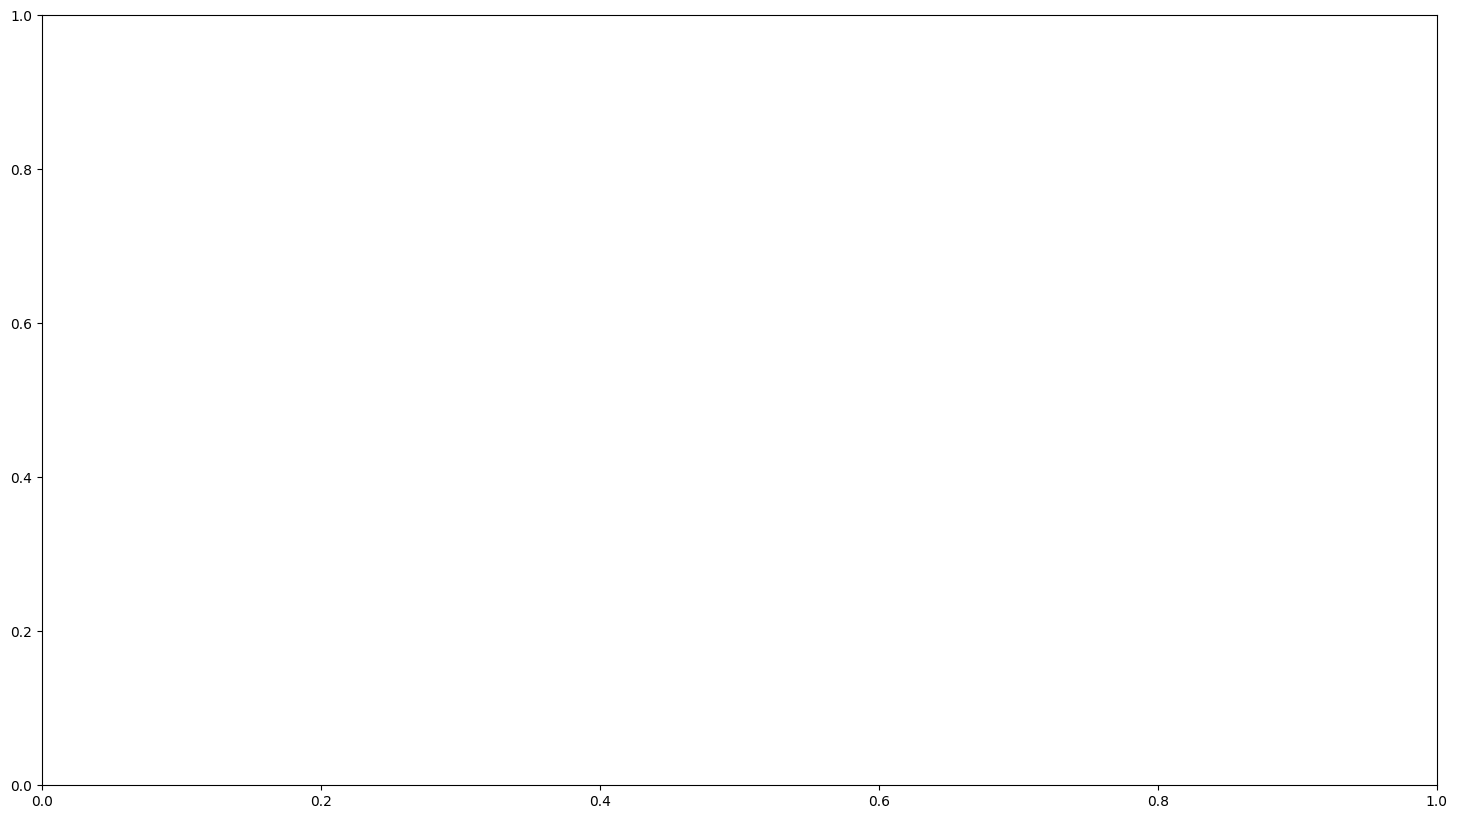

In [22]:
# 3. Prepare data for 'Without Genotype' models
print("Preparing alluvial data for models WITHOUT genotype...")
df_alluvial_without = get_patient_level_classifications(all_y_true_without, all_y_pred_without, method_names, y, common_ids, skf)

# 4. Generate and save the alluvial plot for 'Without Genotype' models
print("Generating alluvial plot for models WITHOUT genotype...")
plot_alluvial_diagram(df_alluvial_without, "(Without Genotype)")

print("Alluvial plot generation for 'Without Genotype' complete!")

Preparing alluvial data for models WITH genotype...
Generating alluvial plot for models WITH genotype...


TypeError: 'module' object is not callable

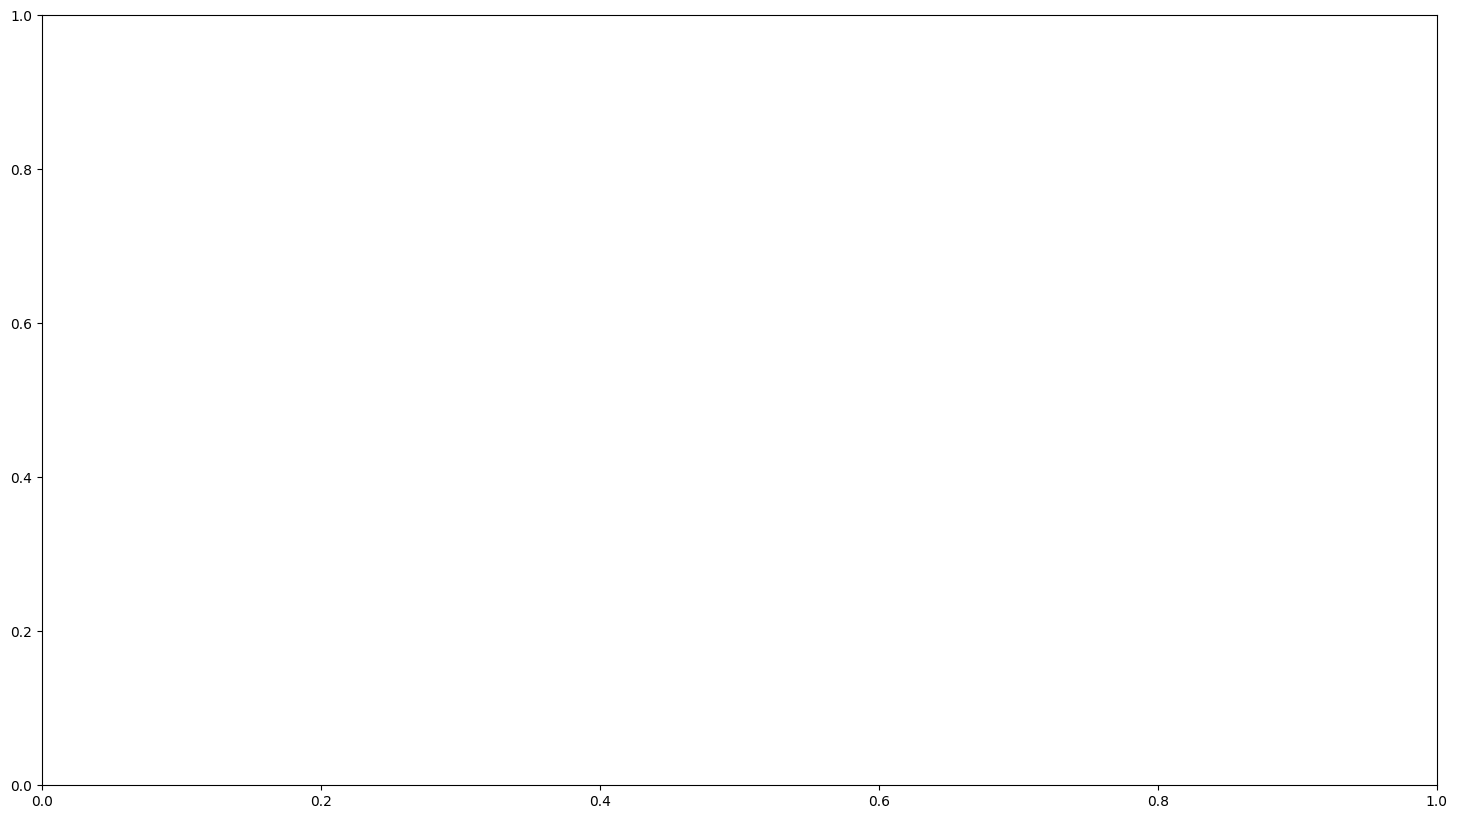

In [18]:
# 1. Prepare data for 'With Genotype' models
print("Preparing alluvial data for models WITH genotype...")
df_alluvial_with = get_patient_level_classifications(all_y_true_with, all_y_pred_with, method_names, y, common_ids, skf)

# 2. Generate and save the alluvial plot for 'With Genotype' models
print("Generating alluvial plot for models WITH genotype...")
plot_alluvial_diagram(df_alluvial_with, "(With Genotype)")

print("Alluvial plot generation for 'With Genotype' complete!")

Preparing alluvial data for models WITHOUT genotype...
Generating alluvial plot for models WITHOUT genotype...


TypeError: 'module' object is not callable

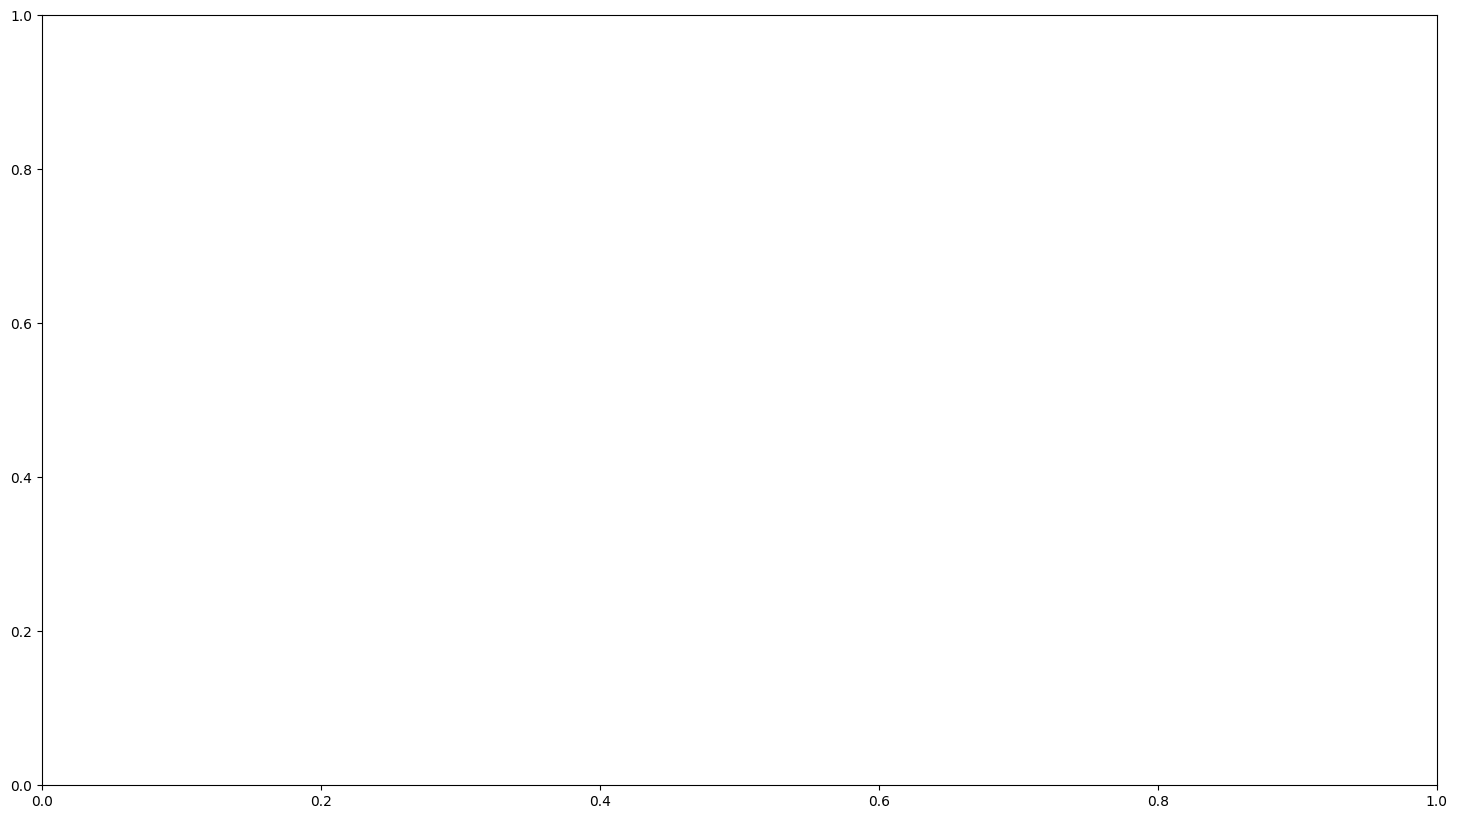

In [19]:
# 3. Prepare data for 'Without Genotype' models
print("Preparing alluvial data for models WITHOUT genotype...")
df_alluvial_without = get_patient_level_classifications(all_y_true_without, all_y_pred_without, method_names, y, common_ids, skf)

# 4. Generate and save the alluvial plot for 'Without Genotype' models
print("Generating alluvial plot for models WITHOUT genotype...")
plot_alluvial_diagram(df_alluvial_without, "(Without Genotype)")

print("Alluvial plot generation for 'Without Genotype' complete!")

In [25]:
import sys
!{sys.executable} -m pip install umap-learn

### UMAP Visualization of Patient Classes

To visualize the patient population structure, we'll use Uniform Manifold Approximation and Projection (UMAP). This dimensionality reduction technique is particularly good at preserving both local and global data structure. Each patient will be represented as a point, colored by their treatment response (0 or 1), allowing us to observe potential clustering or separation of these classes in the embedded space.

Since the 'Late Fusion without genotype' model performed best, we will use the combined `expression` and `methylation` modalities for the UMAP visualization. The data will first be preprocessed (imputation, feature selection, and standardization) on the entire dataset.

In [28]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif

# Helper function to preprocess the full dataset for UMAP and heatmap
def preprocess_full_data(X, y, k_features=200):
    # Impute missing values with column means
    col_means = np.nanmean(X, axis=0)
    X = np.where(np.isnan(X), col_means, X)

    # Feature selection using f_classif
    f_scores, _ = f_classif(X, y)
    f_scores = np.nan_to_num(f_scores)
    # Get indices of top k_features
    top_idx = np.argsort(f_scores)[-k_features:]
    X_selected = X[:, top_idx]

    # Standardize the data
    scaler = StandardScaler().fit(X_selected)
    X_scaled = scaler.transform(X_selected)
    return X_scaled, top_idx # Return selected feature indices as well

# Combine modalities without genotype for UMAP
# Use 'expression' and 'methylation' as per the best model context
X_umap_data = np.hstack([modalities_no_genotype['expression'], modalities_no_genotype['methylation']])

# Preprocess the combined data, getting back the selected feature indices
X_preprocessed_for_umap, selected_feature_indices = preprocess_full_data(X_umap_data, y, k_features=200)

# Apply UMAP dimensionality reduction to the preprocessed data
reducer = umap.UMAP(random_state=42, n_components=2) # 2 components for 2D visualization
umap_embedding = reducer.fit_transform(X_preprocessed_for_umap)

# Create a DataFrame for plotting
umap_df = pd.DataFrame(umap_embedding, columns=['UMAP_1', 'UMAP_2'])
umap_df['True_Label'] = y # Add true labels for coloring

# Ensure output directory exists
output_dir = "./umap_visualizations"
os.makedirs(output_dir, exist_ok=True)

# Plotting
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(
    x='UMAP_1',
    y='UMAP_2',
    hue='True_Label',
    palette='viridis', # A good perceptually uniform colormap
    data=umap_df,
    s=50, # Marker size
    alpha=0.7, # Transparency
    edgecolor='w', # White edge around markers
    linewidth=0.5, # Edge width
    ax=ax
)

ax.set_title('UMAP Visualization of Patients (Expression + Methylation)', fontsize=16)
ax.set_xlabel('UMAP Dimension 1', fontsize=12)
ax.set_ylabel('UMAP Dimension 2', fontsize=12)
ax.legend(title='Treatment Response', loc='best')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save figures
png_filename = os.path.join(output_dir, 'umap_visualization_expression_methylation.png')
pdf_filename = os.path.join(output_dir, 'umap_visualization_expression_methylation.pdf')

plt.savefig(png_filename, dpi=300)
print(f"Saved PNG: {png_filename}")
plt.savefig(pdf_filename, dpi=300)
print(f"Saved PDF: {pdf_filename}")
plt.close()

print("UMAP visualization generated successfully!")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved PNG: ./umap_visualizations/umap_visualization_expression_methylation.png
Saved PDF: ./umap_visualizations/umap_visualization_expression_methylation.pdf
UMAP visualization generated successfully!


In [29]:
# --- Heatmap Generation --- #

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os

# Ensure output directory exists for heatmaps
heatmap_output_dir = "./heatmaps"
os.makedirs(heatmap_output_dir, exist_ok=True)

# 1. Get original feature names for the selected features
# First, concatenate all original feature names in the order they were combined for X_umap_data
all_original_feature_names = list(expr.columns) + list(meth.columns)

# Map the selected_feature_indices back to their original names
selected_feature_names = [all_original_feature_names[i] for i in selected_feature_indices]

# 2. Prepare DataFrame for heatmap
# X_preprocessed_for_umap contains the scaled values of the selected features for all patients
# common_ids is already sorted and represents patient IDs

heatmap_df = pd.DataFrame(
    X_preprocessed_for_umap,
    index=common_ids,
    columns=selected_feature_names
)

# 3. Create patient labels for row annotation
# 'y' contains the true labels (0 or 1). We need to map them to 'Non-Responder' and 'Responder'.
patient_labels = pd.Series(y, index=common_ids).map({0: 'Non-Responder', 1: 'Responder'})

# Define color palette for patient labels
label_colors = patient_labels.map({'Non-Responder': 'blue', 'Responder': 'red'})

# 4. Generate publication-quality heatmap with clustering
# Using 'viridis' or 'mako' for a clean, perceptually uniform color palette
# We cluster both rows (patients) and columns (features)

fig = sns.clustermap(
    heatmap_df,
    cmap='viridis', # A good perceptually uniform colormap
    row_colors=label_colors, # Annotate rows with patient response
    col_cluster=True, # Cluster features
    row_cluster=True, # Cluster patients
    figsize=(12, 10), # Adjust size as needed
    dendrogram_ratio=(.1, .2), # Adjust dendrogram size
    cbar_pos=(0.02, 0.8, 0.03, 0.15), # Position of the color bar (left, bottom, width, height)
    xticklabels=False, # Hide x-axis labels for many features for clarity
    yticklabels=False # Hide y-axis labels for many patients for clarity
)

# Customize the plot
fig.ax_row_dendrogram.set_visible(True)
fig.ax_col_dendrogram.set_visible(True)

# Add a custom legend for patient labels
handles = [plt.Line2D([0,0],[0,0], color=v, marker='o', linestyle='', label=k) for k,v in {'Non-Responder': 'blue', 'Responder': 'red'}.items()]
fig.ax_col_dendrogram.legend(handles=handles, loc='center', title='Treatment Response', bbox_to_anchor=(0.5, 1.2))

fig.fig.suptitle('Heatmap of Selected Features (Expression + Methylation)', fontsize=16, y=1.02) # Title for the whole figure

# 5. Export the heatmap as PNG and PDF files
png_filename = os.path.join(heatmap_output_dir, 'publication_heatmap_expression_methylation.png')
pdf_filename = os.path.join(heatmap_output_dir, 'publication_heatmap_expression_methylation.pdf')

fig.savefig(png_filename, dpi=300)
print(f"Saved PNG: {png_filename}")
fig.savefig(pdf_filename, dpi=300)
print(f"Saved PDF: {pdf_filename}")

plt.close()

print("Publication-quality heatmap generated successfully!")

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Saved PNG: ./heatmaps/publication_heatmap_expression_methylation.png
Saved PDF: ./heatmaps/publication_heatmap_expression_methylation.pdf
Publication-quality heatmap generated successfully!


### Feature Importance: Top 20 Most Informative Genes/Features

For the 'Late Fusion without genotype' model, feature importance is derived from the `f_classif` statistic used during the preprocessing step to select the most informative features. A higher F-score indicates a feature (gene or CpG site) that better differentiates between the two classes (responders vs. non-responders).

Below is a visualization of the top 20 features ranked by their F-score, providing insight into which molecular markers are most strongly associated with treatment response.

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
from sklearn.feature_selection import f_classif

# Ensure output directory exists
feature_importance_output_dir = "./feature_importance_plots"
os.makedirs(feature_importance_output_dir, exist_ok=True)

# --- Identify top 20 most important features --- #

# Combine modalities without genotype for feature importance analysis
# This is the same combined data used for UMAP and Heatmap (expression + methylation)
X_combined_for_feature_selection = np.hstack([modalities_no_genotype['expression'], modalities_no_genotype['methylation']])

# Impute missing values for feature selection, as f_classif cannot handle NaNs
col_means_fs = np.nanmean(X_combined_for_feature_selection, axis=0)
X_combined_for_feature_selection = np.where(np.isnan(X_combined_for_feature_selection), col_means_fs, X_combined_for_feature_selection)

# Compute F-scores for all combined features (expression + methylation)
f_scores, _ = f_classif(X_combined_for_feature_selection, y)
f_scores = np.nan_to_num(f_scores) # Handle potential NaNs if f_classif produced them

# Create a DataFrame for F-scores and feature names
# all_original_feature_names was created in cell 5d3c4b26
feature_importance_df = pd.DataFrame({
    'feature': all_original_feature_names,
    'f_score': f_scores
})

# Sort by F-score in descending order and get the top 20
top_20_features = feature_importance_df.sort_values(by='f_score', ascending=False).head(20)

print("Top 20 Most Informative Genes/Features (by F-score):")
display(top_20_features)

# --- Generate publication-quality feature importance figure --- #

fig, ax = plt.subplots(figsize=(12, 8)) # Adjust figure size for better readability

sns.barplot(
    x='f_score',
    y='feature',
    data=top_20_features,
    palette='viridis',
    ax=ax
)

ax.set_title('Top 20 Most Informative Genes/Features (F-score)', fontsize=16)
ax.set_xlabel('F-score (Feature Importance)', fontsize=12)
ax.set_ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save figures
png_filename_fi = os.path.join(feature_importance_output_dir, 'top_20_feature_importance.png')
pdf_filename_fi = os.path.join(feature_importance_output_dir, 'top_20_feature_importance.pdf')

plt.savefig(png_filename_fi, dpi=300)
print(f"Saved PNG: {png_filename_fi}")
plt.savefig(pdf_filename_fi, dpi=300)
print(f"Saved PDF: {pdf_filename_fi}")

plt.close()

print("Feature importance plot generated successfully!")

Top 20 Most Informative Genes/Features (by F-score):


,feature,f_score
2193,cg22868518,21.668365
11554,cg26790981,18.275905
3301,cg10654546,17.401295
11027,cg10005260,14.707187
5730,cg06146160,14.308921
37,AKAP12,14.229273
7370,cg23840797,14.170088
5711,cg21202558,14.009780
2977,cg19094530,13.804628
2891,cg07466807,13.714359


/tmp/ipykernel_499/3905253655.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Saved PNG: ./feature_importance_plots/top_20_feature_importance.png
Saved PDF: ./feature_importance_plots/top_20_feature_importance.pdf
Feature importance plot generated successfully!


In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# --- Re-import necessary libraries and functions to make this cell self-contained ---
# from 23pYAhwF-3Ai
import torch
import torch.nn as nn
import torch.nn.functional as F

# from mUmRkasPJyOa
def load_omic(path, feature_col):
    df = pd.read_csv(path).set_index(feature_col).T
    df.index = df.index.astype(str)
    return df

# DATA_DIR and common_ids should be available from previous cells, but re-loading for self-containment if needed
if 'DATA_DIR' not in globals():
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/Data_Sairi'

if 'modalities' not in globals() or 'modalities_no_genotype' not in globals() or 'y' not in globals() or 'skf' not in globals():
    print("Reloading omic data and setting up cross-validation.")
    condition = pd.read_csv(os.path.join(DATA_DIR, 'Patient_condition.csv'))
    condition['ID'] = condition['ID'].astype(str)
    condition = condition.set_index('ID')
    y_series = (condition['RES'] == 'RES').astype(int)

    geno = load_omic(os.path.join(DATA_DIR, 'Genotype_input.csv'), 'SNP')
    expr = load_omic(os.path.join(DATA_DIR, 'Gene_expression_input.csv'), 'Gene')
    meth = load_omic(os.path.join(DATA_DIR, 'DNA_methylation_input.csv'), 'CpG_sites')

    common_ids = geno.index.intersection(expr.index).intersection(meth.index).intersection(y_series.index)
    common_ids = sorted(common_ids, key=lambda x: int(x))

    geno, expr, meth = geno.loc[common_ids], expr.loc[common_ids], meth.loc[common_ids]
    y = y_series.loc[common_ids].values

    modalities = {'genotype': geno.values.astype(np.float32),
                  'expression': expr.values.astype(np.float32),
                  'methylation': meth.values.astype(np.float32)}

    modalities_no_genotype = {'expression': modalities['expression'],
                               'methylation': modalities['methylation']}
    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

# from Mqr1XosvKC7G
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler
def preprocess_fold(X_train, X_test, y_train, k_features=200):
    col_means = np.nanmean(X_train, axis=0)
    X_train = np.where(np.isnan(X_train), col_means, X_train)
    X_test = np.where(np.isnan(X_test), col_means, X_test)

    f_scores, _ = f_classif(X_train, y_train)
    f_scores = np.nan_to_num(f_scores)
    top_idx = np.argsort(f_scores)[-k_features:]
    X_train, X_test = X_train[:, top_idx], X_test[:, top_idx]

    scaler = StandardScaler().fit(X_train)
    return scaler.transform(X_train), scaler.transform(X_test)

# from DgyFbiqLFgZ4
from sklearn.metrics.pairwise import cosine_similarity
def build_knn_graph(X, k=10):
    k = min(k, X.shape[0] - 1)
    S = cosine_similarity(X)
    np.fill_diagonal(S, 0)
    n = len(S)
    A = np.zeros_like(S)
    for i in range(n):
        nbrs = np.argsort(S[i])[-k:]
        A[i, nbrs] = S[i, nbrs]
    A = np.maximum(A, A.T)
    return A

def normalize_adj(A):
    A_hat = A + np.eye(A.shape[0])
    D = np.diag(1.0 / np.sqrt(A_hat.sum(1)))
    return D @ A_hat @ D

# from 8wg9GJ35KS45
class GraphConv(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=True)

    def forward(self, X, A):
        return A @ self.W(X)

class GCNEncoder(nn.Module):
    def __init__(self, in_dim,
                 hidden1=200,
                 hidden2=200,
                 out_dim=100,
                 dropout=0.5):
        super().__init__()
        self.gc1 = GraphConv(in_dim, hidden1)
        self.gc2 = GraphConv(hidden1, hidden2)
        self.gc3 = GraphConv(hidden2, out_dim)
        self.dropout = dropout

    def forward(self, X, A):
        X = F.leaky_relu(self.gc1(X, A), 0.25)
        X = F.dropout(X, self.dropout, training=self.training)
        X = F.leaky_relu(self.gc2(X, A), 0.25)
        X = F.dropout(X, self.dropout, training=self.training)
        X = F.leaky_relu(self.gc3(X, A), 0.25)
        return X

class ModalityModel(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.encoder = GCNEncoder(in_dim)
        self.head = nn.Linear(100, 2)

    def forward(self, X, A_norm):
        return self.head(self.encoder(X, A_norm))

def train_modality_model_masked(X_all, A_norm, y_labeled, train_positions, epochs=100, lr=0.005):
    model = ModalityModel(X_all.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    X_t = torch.tensor(X_all, dtype=torch.float32)
    A_t = torch.tensor(A_norm, dtype=torch.float32)
    y_t = torch.tensor(y_labeled, dtype=torch.long)
    train_pos_t = torch.tensor(train_positions, dtype=torch.long)

    for _ in range(epochs):
        opt.zero_grad()
        logits_all = model(X_t, A_t)
        loss = F.cross_entropy(logits_all[train_pos_t], y_t)
        loss.backward()
        opt.step()
    return model

def train_modality_model_masked_ensemble(X_all, A_norm, y_labeled, train_positions,
                                          n_runs=3, epochs=200, lr=0.005):
    all_logits = []
    X_t = torch.tensor(X_all, dtype=torch.float32)
    A_t = torch.tensor(A_norm, dtype=torch.float32)
    for seed in range(n_runs):
        torch.manual_seed(seed)
        model = train_modality_model_masked(X_all, A_norm, y_labeled, train_positions, epochs=epochs, lr=lr)
        with torch.no_grad():
            all_logits.append(model(X_t, A_t))
    return torch.stack(all_logits).mean(dim=0)

# from qJyOR5OqKWrH
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
def eval_sgof(modalities, y, train_idx, test_idx, k_features=200, n_runs=3, verbose=False):
    inner_train_idx, inner_val_idx = train_test_split(
        train_idx, test_size=0.25, stratify=y[train_idx], random_state=0
    )

    weights = {}
    test_logits = {}

    for name, X in modalities.items():
        # Step 1: score modality signal -- feature selection using ONLY inner-train
        X_in_tr, X_in_val = preprocess_fold(X[inner_train_idx], X[inner_val_idx], y[inner_train_idx], k_features)
        X_inner_all = np.vstack([X_in_tr, X_in_val])
        n_inner_train = X_in_tr.shape[0]
        A_inner_all = normalize_adj(build_knn_graph(X_inner_all, k=10))

        inner_logits = train_modality_model_masked_ensemble(
            X_inner_all, A_inner_all, y[inner_train_idx],
            train_positions=np.arange(n_inner_train), n_runs=n_runs
        )
        val_probs = F.softmax(inner_logits[n_inner_train:], dim=1)[:, 1].numpy()
        a_m = roc_auc_score(y[inner_val_idx], val_probs)
        weights[name] = max(a_m - 0.5, 0)

        # Step 2: full outer-train feature selection, real test prediction
        Xtr_full, Xte = preprocess_fold(X[train_idx], X[test_idx], y[train_idx], k_features)
        X_full_all = np.vstack([Xtr_full, Xte])
        n_tr = Xtr_full.shape[0]
        A_full_all = normalize_adj(build_knn_graph(X_full_all, k=10))

        final_logits = train_modality_model_masked_ensemble(
            X_full_all, A_full_all, y[train_idx],
            train_positions=np.arange(n_tr), n_runs=n_runs
        )
        test_logits[name] = final_logits[n_tr:]

    total_s = sum(weights.values())
    if total_s == 0:
        weights = {k: 1/len(weights) for k in weights}
    else:
        weights = {k: v/total_s for k, v in weights.items()}

    normalized_logits = {name: test_logits[name] / (test_logits[name].std().item() + 1e-6) for name in modalities}
    fused_logits = sum(weights[name] * normalized_logits[name] for name in modalities)
    fused_probs = F.softmax(fused_logits, dim=1)[:, 1].detach().numpy()

    return fused_probs, weights


# --- Re-compute sgof_weights_with and sgof_weights_without ---
sgof_weights_with, sgof_weights_without = [], []

print("Recalculating SGOF weights across cross-validation folds...")
for fold_i, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(y)), y)):
    # With Genotype
    _, w_with = eval_sgof(modalities, y, train_idx, test_idx)
    sgof_weights_with.append(w_with)

    # Without Genotype
    _, w_without = eval_sgof(modalities_no_genotype, y, train_idx, test_idx)
    sgof_weights_without.append(w_without)
print("SGOF weight recalculation complete.")


# Ensure output directory exists
sgof_contribution_output_dir = "./sgof_modality_contribution_plots"
os.makedirs(sgof_contribution_output_dir, exist_ok=True)

# --- Calculate Average SGOF Weights ---
# The `sgof_weights_with` and `sgof_weights_without` lists contain dictionaries
# with modality weights for each cross-validation fold.
# We need to average these weights across all folds.

# Average weights for 'With Genotype' scenario
avg_sgof_weights_with = {
    modality: np.mean([fold_weights[modality] for fold_weights in sgof_weights_with])
    for modality in modalities.keys()
}

# Average weights for 'Without Genotype' scenario
avg_sgof_weights_without = {
    modality: np.mean([fold_weights[modality] for fold_weights in sgof_weights_without])
    for modality in modalities_no_genotype.keys()
}

print("\nAverage SGOF Weights (With Genotype):")
for k, v in avg_sgof_weights_with.items():
    print(f"  {k.capitalize()}: {v:.3f}")

print("\nAverage SGOF Weights (Without Genotype):")
for k, v in avg_sgof_weights_without.items():
    print(f"  {k.capitalize()}: {v:.3f}")

# --- Visualization: Pie Charts for Modality Contribution ---

def plot_pie_chart_sgof(weights_dict, title_suffix, filename_suffix):
    labels = [k.capitalize() for k in weights_dict.keys()]
    sizes = list(weights_dict.values())

    fig, ax = plt.subplots(figsize=(10, 10))
    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=plt.cm.Paired.colors, # Use a categorical colormap
        wedgeprops={'edgecolor': 'black'}
    )

    # Equal aspect ratio ensures that pie is drawn as a circle.
    ax.axis('equal')
    ax.set_title(f'SGOF Modality Contribution {title_suffix}', fontsize=16)

    # Enhance autopct text for better readability
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontsize(12)
    for text in texts:
        text.set_fontsize(12)

    plt.tight_layout()

    # Save figures
    png_filename = os.path.join(sgof_contribution_output_dir, f'sgof_modality_contribution_{filename_suffix}.png')
    pdf_filename = os.path.join(sgof_contribution_output_dir, f'sgof_modality_contribution_{filename_suffix}.pdf')

    plt.savefig(png_filename, dpi=300)
    print(f"Saved PNG: {png_filename}")
    plt.savefig(pdf_filename, dpi=300)
    print(f"Saved PDF: {pdf_filename}")
    plt.close()

# Generate pie chart for 'With Genotype'
plot_pie_chart_sgof(avg_sgof_weights_with, "(With Genotype)", "with_genotype")

# Generate pie chart for 'Without Genotype'
plot_pie_chart_sgof(avg_sgof_weights_without, "(Without Genotype)", "without_genotype")

print("\nSGOF modality contribution visualizations generated successfully!")

Recalculating SGOF weights across cross-validation folds...


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 44098 232948] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


SGOF weight recalculation complete.

Average SGOF Weights (With Genotype):
  Genotype: 0.017
  Expression: 0.670
  Methylation: 0.313

Average SGOF Weights (Without Genotype):
  Expression: 0.681
  Methylation: 0.319
Saved PNG: ./sgof_modality_contribution_plots/sgof_modality_contribution_with_genotype.png
Saved PDF: ./sgof_modality_contribution_plots/sgof_modality_contribution_with_genotype.pdf
Saved PNG: ./sgof_modality_contribution_plots/sgof_modality_contribution_without_genotype.png
Saved PDF: ./sgof_modality_contribution_plots/sgof_modality_contribution_without_genotype.pdf

SGOF modality contribution visualizations generated successfully!


### Omics Modality Similarity: Correlation Matrix of Patient Similarity Graphs

To understand the relationships between the different omics datasets (Genotype, Gene Expression, and DNA Methylation), we can analyze how similar their patient-patient affinity matrices are. Here, we construct a k-Nearest Neighbors graph for each modality, where edge weights represent cosine similarity between patients. We then compute the pairwise Pearson correlation between the flattened adjacency matrices of these graphs. A higher correlation value indicates that patients who are similar based on one omic are also similar based on another omic, suggesting alignment in their underlying biological structure.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Re-import necessary libraries and functions to make this cell self-contained ---
# from mUmRkasPJyOa, assuming DATA_DIR is already globally defined
if 'DATA_DIR' not in globals():
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/Data_Sairi'

# Re-define load_omic and modalities if they are not in global scope
if 'modalities' not in globals() or 'y' not in globals() or 'common_ids' not in globals():
    print("Reloading omic data and patient conditions.")
    def load_omic(path, feature_col):
        df = pd.read_csv(path).set_index(feature_col).T
        df.index = df.index.astype(str)
        return df

    condition = pd.read_csv(os.path.join(DATA_DIR, 'Patient_condition.csv'))
    condition['ID'] = condition['ID'].astype(str)
    condition = condition.set_index('ID')
    y_series = (condition['RES'] == 'RES').astype(int)

    geno = load_omic(os.path.join(DATA_DIR, 'Genotype_input.csv'), 'SNP')
    expr = load_omic(os.path.join(DATA_DIR, 'Gene_expression_input.csv'), 'Gene')
    meth = load_omic(os.path.join(DATA_DIR, 'DNA_methylation_input.csv'), 'CpG_sites')

    common_ids = geno.index.intersection(expr.index).intersection(meth.index).intersection(y_series.index)
    common_ids = sorted(common_ids, key=lambda x: int(x))

    geno, expr, meth = geno.loc[common_ids], expr.loc[common_ids], meth.loc[common_ids]
    y = y_series.loc[common_ids].values

    modalities = {'genotype': geno.values.astype(np.float32),
                  'expression': expr.values.astype(np.float32),
                  'methylation': meth.values.astype(np.float32)}

# Re-define build_knn_graph (from DgyFbiqLFgZ4)
from sklearn.metrics.pairwise import cosine_similarity
def build_knn_graph(X, k=10):
    k = min(k, X.shape[0] - 1)
    S = cosine_similarity(X)
    np.fill_diagonal(S, 0)
    n = len(S)
    A = np.zeros_like(S)
    for i in range(n):
        nbrs = np.argsort(S[i])[-k:]
        A[i, nbrs] = S[i, nbrs]
    A = np.maximum(A, A.T)
    return A

# --- Build Patient Similarity Graphs for each modality ---
p_similarity_graphs = {}
print("Building patient similarity graphs for each modality...")
for name, X_data_original in modalities.items():
    print(f"  Processing {name}...")
    # Impute NaN values if any, before building graph
    X_data_imputed = X_data_original.copy()
    if np.isnan(X_data_imputed).any():
        col_means = np.nanmean(X_data_imputed, axis=0)
        # Fill potential NaNs in col_means (e.g., if a whole column was NaN)
        col_means[np.isnan(col_means)] = 0 # Replace with 0 or a more appropriate value
        X_data_imputed = np.where(np.isnan(X_data_imputed), col_means, X_data_imputed)

    p_similarity_graphs[name] = build_knn_graph(X_data_imputed, k=10)
print("Patient similarity graphs built.")

# --- Calculate Correlation Matrix between Patient Similarity Graphs ---
modality_names = list(p_similarity_graphs.keys())
num_modalities = len(modality_names)

correlation_matrix = np.zeros((num_modalities, num_modalities))

print("Calculating pairwise correlations between modality similarity graphs...")
for i in range(num_modalities):
    for j in range(num_modalities):
        modality1 = modality_names[i]
        modality2 = modality_names[j]

        graph1_flat = p_similarity_graphs[modality1].flatten()
        graph2_flat = p_similarity_graphs[modality2].flatten()

        # Compute Pearson correlation coefficient
        # np.corrcoef returns a 2x2 matrix, we need the off-diagonal element
        correlation = np.corrcoef(graph1_flat, graph2_flat)[0, 1]
        correlation_matrix[i, j] = correlation

correlation_df = pd.DataFrame(correlation_matrix, index=modality_names, columns=modality_names)

print("Correlation matrix of patient similarity graphs:")
display(correlation_df)

# --- Visualize the Correlation Matrix ---
correlation_output_dir = "./correlation_matrices"
os.makedirs(correlation_output_dir, exist_ok=True)

plt.figure(figsize=(8, 7))
sns.heatmap(
    correlation_df,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)
plt.title('Correlation Matrix of Omics Patient Similarity Graphs', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save figures
png_filename = os.path.join(correlation_output_dir, 'omics_patient_similarity_correlation_matrix.png')
pdf_filename = os.path.join(correlation_output_dir, 'omics_patient_similarity_correlation_matrix.pdf')

plt.savefig(png_filename, dpi=300)
print(f"Saved PNG: {png_filename}")
plt.savefig(pdf_filename, dpi=300)
print(f"Saved PDF: {pdf_filename}")
plt.close()

print("Omics modality similarity correlation matrix generated successfully!")

Building patient similarity graphs for each modality...
  Processing genotype...
  Processing expression...
  Processing methylation...
Patient similarity graphs built.
Calculating pairwise correlations between modality similarity graphs...
Correlation matrix of patient similarity graphs:


,genotype,expression,methylation
genotype,1.000000,-0.004632,0.018817
expression,-0.004632,1.000000,0.098577
methylation,0.018817,0.098577,1.000000


Saved PNG: ./correlation_matrices/omics_patient_similarity_correlation_matrix.png
Saved PDF: ./correlation_matrices/omics_patient_similarity_correlation_matrix.pdf
Omics modality similarity correlation matrix generated successfully!
